In [1]:
import numpy as np
import healpy as hp
from astropy.io import fits
from astropy.table import Table
from astropy import units as u
from astropy.coordinates import SkyCoord
import pandas as pd

import astropy.coordinates as ac
#from mpl_toolkits.basemap import Basemap
from matplotlib.colors import LogNorm

from gala.coordinates import MagellanicStreamNidever08
import matplotlib.pyplot as plt
import os

#%matplotlib inline# set up the plotting
# set font size
plt.rcParams.update({'font.size': 18})
# set the figure size
plt.rcParams.update({'figure.figsize': (10, 7)})
# set the font to latex
plt.rcParams.update({'text.usetex': True})

# Source - https://stackoverflow.com/a
# Posted by Sina Mansour L.
# Retrieved 2026-01-20, License - CC BY-SA 4.0

plt.rcParams.update({
"text.usetex": True,
"font.family": "sans-serif",
"font.sans-serif": ["Helvetica"]})


In [2]:
plots_dir = '/Users/mncavieres/Documents/2024-1/Delve/Plots/stream_results'

# Load XSHOOTER data

In [3]:
xshooter_merged = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/xshooter_nested_distance_merged.fits')
nested_results = Table.read("/Users/mncavieres/Documents/2024-1/Delve/Data/xshooter_ested_ALICE/fit_results.fits")

from astropy.table import join
# add to xshooter merger the columns from nested results that match on 'source_id' and are not already present
for col in nested_results.colnames:
    if col not in xshooter_merged.colnames and col != 'source_id':
        # join on source_id
        xshooter_merged = join(xshooter_merged, nested_results[['source_id', col]], keys='source_id', join_type='left')


# Compute angular momentum XSHOOTER

In [4]:
def compute_angular_momentum(x,y,z, vx,vy,vz):
    Lx = y*vz - z*vy
    Ly = z*vx - x*vz
    Lz = x*vy - y*vx
    return Lx, Ly, Lz

In [5]:
# get xzy and vxvyvz for xshooter_merged
coords = SkyCoord(ra=xshooter_merged['ra']*u.degree, dec=xshooter_merged['dec']*u.degree,
                  distance=xshooter_merged['dist_pc_p50']*u.pc,
                  pm_ra_cosdec=xshooter_merged['pmra']*u.mas/u.yr, 
                  pm_dec=xshooter_merged['pmdec']*u.mas/u.yr,
                  radial_velocity=xshooter_merged['hel_vel']*u.km/u.s)
xshooter_merged['x'] = coords.galactocentric.x.to(u.kpc)
xshooter_merged['y'] = coords.galactocentric.y.to(u.kpc)
xshooter_merged['z'] = coords.galactocentric.z.to(u.kpc)
xshooter_merged['vx'] = coords.galactocentric.v_x.to(u.km/u.s)
xshooter_merged['vy'] = coords.galactocentric.v_y.to(u.km/u.s)
xshooter_merged['vz'] = coords.galactocentric.v_z.to(u.km/u.s)

lx, ly, lz = compute_angular_momentum(xshooter_merged['x'], xshooter_merged['y'], xshooter_merged['z'],
                                      xshooter_merged['vx'], xshooter_merged['vy'], xshooter_merged['vz'])
xshooter_merged['Lx'] = lx
xshooter_merged['Ly'] = ly
xshooter_merged['Lz'] = lz

# Same for DESI sources to use as background for galaxy

In [6]:
desi_stars = Table.read('/Users/mncavieres/Documents/2025-1/DESI_HVS/Data/DESI/distxDESI_processed.fits')


In [7]:
desi_coords = SkyCoord(ra=desi_stars['ra'], dec=desi_stars['dec'], distance=desi_stars['DIST'],
                       pm_ra_cosdec=desi_stars['pmra'], pm_dec=desi_stars['pmdec'], radial_velocity=desi_stars['VRAD_2'])
desi_stars['x'] = desi_coords.galactocentric.x.to(u.kpc)
desi_stars['y'] = desi_coords.galactocentric.y.to(u.kpc)
desi_stars['z'] = desi_coords.galactocentric.z.to(u.kpc)
desi_stars['vx'] = desi_coords.galactocentric.v_x.to(u.km/u.s)
desi_stars['vy'] = desi_coords.galactocentric.v_y.to(u.km/u.s)
desi_stars['vz'] = desi_coords.galactocentric.v_z.to(u.km/u.s)

desi_stars['lx'], desi_stars['ly'], desi_stars['lz'] = compute_angular_momentum(desi_stars['x'], desi_stars['y'], desi_stars['z'],
                                                                              desi_stars['vx'], desi_stars['vy'], desi_stars['vz'])

In [8]:
# clean nans from desi_stars in any angular momentum column
desi_stars = desi_stars[~np.isnan(desi_stars['lx']) & ~np.isnan(desi_stars['ly']) & ~np.isnan(desi_stars['lz'])]

In [9]:
# select desi stars in the halo by requiring |z| > 3 kpc
desi_halo_stars = desi_stars[np.abs(desi_stars['z']) > 3*u.kpc]

print(f"Number of DESI halo stars: {len(desi_halo_stars)}")

Number of DESI halo stars: 958277


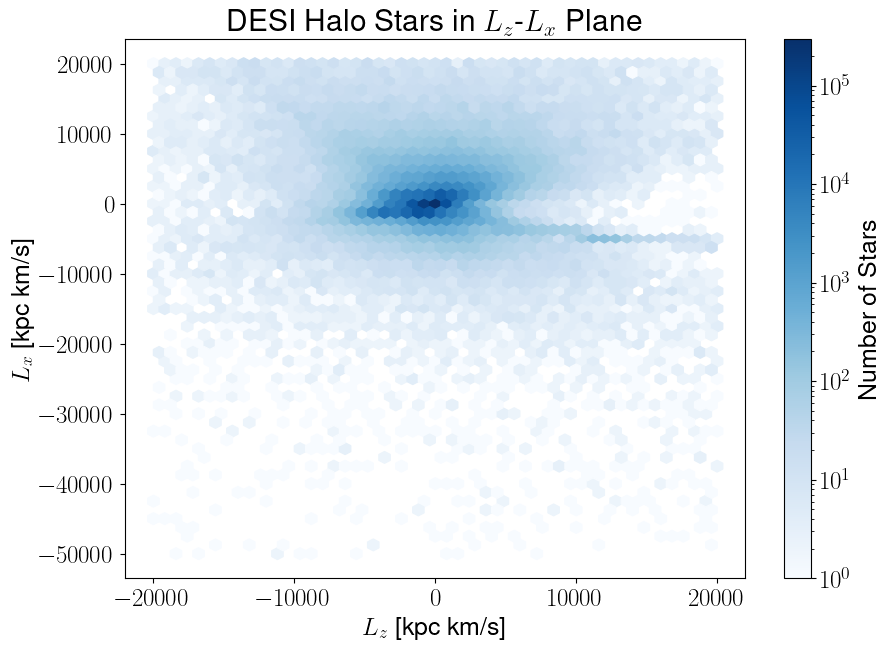

In [32]:
# contour plot of desi halo stars in the Lz-Lx plane

fig, ax = plt.subplots(figsize=(10, 7))
hb = ax.hexbin(desi_halo_stars['lz'], desi_halo_stars['lx'], gridsize=50, cmap='Blues',
               extent=(-20000, 20000, -50000, 20000),
               norm=LogNorm(),
                mincnt=0)

ax.set_xlabel(r'$L_z$ [kpc km/s]')
ax.set_ylabel(r'$L_x$ [kpc km/s]')
ax.set_title('DESI Halo Stars in $L_z$-$L_x$ Plane')
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Number of Stars')
plt.savefig(os.path.join(plots_dir, 'desi_halo_stars_lz_lx.png'), dpi=300)
plt.show()

In [11]:

def plot_sigma_contours2(x, y, ax = None, xlim=(-60, 60), ylim=(-60, 60), bw_method='scott', show= True, save = False, save_path=plots_dir, name='star'):
    """
    Plot the 1σ and 2σ contours of closest approach points in the X-Y plane.

    Parameters:
    - origins: list of tuples
      List of positions (X, Y, Z) at the closest approach for each sample.
    - xlim: tuple
      Limits for the X-axis (default: (-60, 60)).
    - ylim: tuple
      Limits for the Y-axis (default: (-60, 60)).
    """
    # Extract X, Y positions from origins
    #x = np.array([origin[0] for origin in origins])
    #y = np.array([origin[1] for origin in origins])
    from scipy.stats import gaussian_kde
    # Create a 2D KDE
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy, bw_method=bw_method)
    xi, yi = np.linspace(xlim[0], xlim[1], 100), np.linspace(ylim[0], ylim[1], 100)
    xi, yi = np.meshgrid(xi, yi)
    zi = kde(np.vstack([xi.flatten(), yi.flatten()])).reshape(xi.shape)
    
    # Normalize the KDE to get cumulative probabilities
    zi_flat = zi.flatten()
    sorted_zi = np.sort(zi_flat)
    cumsum_zi = np.cumsum(sorted_zi) / np.sum(sorted_zi)

    # Determine contour levels for 1σ (68.26%) and 2σ (95.44%)
    level_1sigma = sorted_zi[np.searchsorted(cumsum_zi, 1 - 0.6826)]
    level_2sigma = sorted_zi[np.searchsorted(cumsum_zi, 1- 0.9544)]

    # Find mode of the distribution
    mode_index = np.argmax(zi_flat)
    mode_x, mode_y = xi.flatten()[mode_index], yi.flatten()[mode_index]

    if ax is None:

        fig, ax = plt.subplots(figsize=(10, 10))

    # Plot the KDE with contour levels
   
    #ax.contourf(xi, yi, zi, levels=100, cmap="Blues")
    #fig.colorbar(label="Density")
    ax.contour(xi, yi, zi, levels=[level_2sigma, level_1sigma, zi.max()], colors=['k', 'k', 'k'], 
        linewidths=[2, 2, 2], linestyles=['--', '-','-'], labels=['1σ', '2σ', '0'])
    #ax.contourf(xi, yi, zi, levels=[level_2sigma, level_1sigma, zi.max()], colors=['cyan', 'magenta', 'blue'], alpha=0.5)
    
    # Add annotations
    #ax.scatter(mode_x, mode_y, color='black', label='Mode of Distribution', s=100, marker='x')
    ax.scatter(0, 0, color='red', label='Galactic Center', s=100)  # Galactic Center

    # Add solar circles
    circle1 = plt.Circle((0, 0), 8.21, color='r', fill=False, lw=2, label='8.21 kpc')
    circle2 = plt.Circle((0, 0), 20, color='g', fill=False, linestyle='--', label='20 kpc')
    ax.add_artist(circle1)
    ax.add_artist(circle2)

    # Customize plot
    ax.set_xlabel('X [kpc]')
    ax.set_ylabel('Y [kpc]')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    #ax.set_title('1$\sigma$ and 2σ Contours of Closest Approach Points in X-Y Plane')
    ax.legend(loc='upper right')
    ax.grid(True)
    
    if save:
        if not os.path.exists(save_path):
            os.makedirs(save_path)
            plt.savefig(os.path.join(save_path, name+'.png'))

    if show:
        plt.show()
    
    return ax


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_sigma_contours2_kde_fast(
    x, y, ax=None, xlim=(-60, 60), ylim=(-60, 60),
    bw_method='scott', ngrid=100, max_points=5_000,  # max_points is the key knob
    show=True, save=False, save_path=plots_dir, name='star'
):
    x = np.asarray(x)
    y = np.asarray(y)

    # clip first
    m = (x >= xlim[0]) & (x <= xlim[1]) & (y >= ylim[0]) & (y <= ylim[1])
    x, y = x[m], y[m]

    # subsample for KDE (huge speed win)
    if max_points is not None and x.size > max_points:
        idx = np.random.default_rng(0).choice(x.size, size=max_points, replace=False)
        x, y = x[idx], y[idx]

    kde = gaussian_kde(np.vstack([x, y]), bw_method=bw_method)

    xi = np.linspace(xlim[0], xlim[1], ngrid)
    yi = np.linspace(ylim[0], ylim[1], ngrid)
    xi, yi = np.meshgrid(xi, yi, indexing="xy")

    eval_pts = np.vstack([xi.ravel(), yi.ravel()])
    zi = kde(eval_pts).reshape(xi.shape)

    # levels enclosing given probability mass:
    z = zi.ravel()
    order = np.argsort(z)[::-1]
    c = np.cumsum(z[order]) / np.sum(z[order])

    level_1sigma = z[order][np.searchsorted(c, 0.6826)]
    level_2sigma = z[order][np.searchsorted(c, 0.9544)]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    ax.contour(xi, yi, zi, levels=[level_2sigma, level_1sigma],
               colors='k', linewidths=[2, 2], linestyles=['--', '-'])

    ax.scatter(0, 0, color='red', label='Galactic Center', s=100)
    ax.add_patch(plt.Circle((0, 0), 8.21, color='r', fill=False, lw=2, label='8.21 kpc'))
    ax.add_patch(plt.Circle((0, 0), 20,   color='g', fill=False, lw=2, linestyle='--', label='20 kpc'))

    ax.set_xlabel('X [kpc]')
    ax.set_ylabel('Y [kpc]')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.legend(loc='upper right')
    ax.grid(True)

    if save:
        import os
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(os.path.join(save_path, name + '.png'), dpi=300)

    if show:
        plt.show()

    return ax

# Now same for sims

In [13]:

# transform from Galactocentric to Stream coordinates
from astropy.coordinates import Galactocentric, ICRS

def add_stream_coords(smc1_sim):
    
    # Step 1: Convert RA/Dec to a SkyCoord object
    coords = Galactocentric(
        x=smc1_sim["x"] * u.kpc,
        y=smc1_sim["y"] * u.kpc,
        z=smc1_sim["z"] * u.kpc,
        v_x=smc1_sim["v_x"] * (u.km/u.s),
        v_y=smc1_sim["v_y"] * (u.km/u.s),
        v_z=smc1_sim["v_z"] * (u.km/u.s),
    )
    # Step 2: Convert RA/Dec to Magellanic Stream Coordinates
    mag_stream_coords = coords.transform_to(MagellanicStreamNidever08())

    # Add the new coordinates to the table
    smc1_sim['L_stream'] = mag_stream_coords.L.degree
    smc1_sim['B_stream'] = mag_stream_coords.B.degree
    smc1_sim['pm_l'] = mag_stream_coords.pm_L_cosB
    smc1_sim['pm_b'] = mag_stream_coords.pm_B

    # also add heliocentric radial velocity and distance

    smc1_sim['radial_velocity'] = coords.radial_velocity

    icrs_coords = coords.transform_to(ICRS())

    smc1_sim['distance'] = icrs_coords.distance.kpc
    smc1_sim['ra'] = icrs_coords.ra.degree
    smc1_sim['dec'] = icrs_coords.dec.degree
    smc1_sim['pmra'] = icrs_coords.pm_ra_cosdec
    smc1_sim['pmdec'] = icrs_coords.pm_dec

    return smc1_sim

smc1_sim  = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/for_Camila/SMC/SMC_model1_stars.csv')
smc1_sim = add_stream_coords(smc1_sim)


# now same for the other sim
smc2_sim = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/for_Camila/SMC/SMC_model2_stars.csv')
smc2_sim = add_stream_coords(smc2_sim)

smc1_sim['Lx'], smc1_sim['Ly'], smc1_sim['Lz'] = compute_angular_momentum(smc1_sim['x'], smc1_sim['y'], smc1_sim['z'],
                                                                              smc1_sim['v_x'], smc1_sim['v_y'], smc1_sim['v_z'])
smc2_sim['Lx'], smc2_sim['Ly'], smc2_sim['Lz'] = compute_angular_momentum(smc2_sim['x'], smc2_sim['y'], smc2_sim['z'],
                                                                              smc2_sim['v_x'], smc2_sim['v_y'], smc2_sim['v_z'])

In [17]:
# mask out the region of the simulation that is the main body of the LMC, we can do this in stream coordinates by masking the region around L_stream = 0, B_stream = 0, we can use a circular mask with a radius of 10 degrees
lmc_mask = (np.sqrt(smc1_sim['L_stream']**2 + smc1_sim['B_stream']**2) > 10)
smc1_sim_lmc_masked = smc1_sim[lmc_mask]

lmc_mask = (np.sqrt(smc2_sim['L_stream']**2 + smc2_sim['B_stream']**2) > 10)
smc2_sim_lmc_masked = smc2_sim[lmc_mask]

# mask out the region of the LMC and SMC by using the RA and Dec of the LMC and SMC, we can use a circular mask with a radius of 10 degrees around the center of the LMC and SMC
lmc_center = SkyCoord(ra=80.89416667*u.degree, dec=-69.75611111*u.degree, frame='icrs')
smc_center = SkyCoord(ra=13.18666667*u.degree, dec=-72.82861111*u.degree, frame='icrs')

lmc_mask = (smc1_sim['ra'] - lmc_center.ra.degree)**2 + (smc1_sim['dec'] - lmc_center.dec.degree)**2 > 10**2
smc1_sim_lmc_masked = smc1_sim[lmc_mask]   
lmc_mask = (smc2_sim['ra'] - lmc_center.ra.degree)**2 + (smc2_sim['dec'] - lmc_center.dec.degree)**2 > 10**2
smc2_sim_lmc_masked = smc2_sim[lmc_mask]

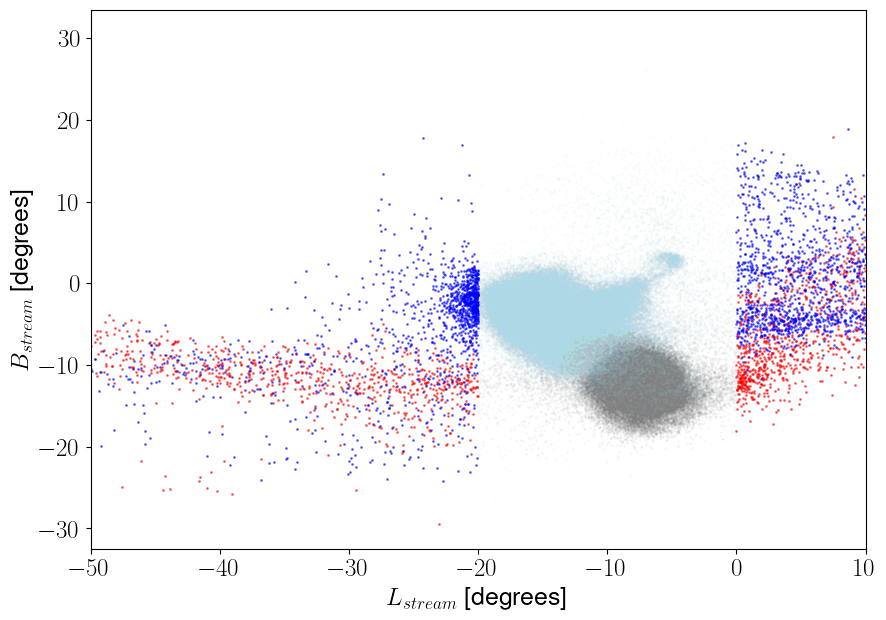

In [45]:
# show the L, B stream masking
fig, ax = plt.subplots(figsize=(10,7))
ax.scatter(smc1_sim['L_stream'], smc1_sim['B_stream'], s=1, color='gray', label='SMC Model 1', alpha=0.05)
ax.scatter(smc2_sim['L_stream'], smc2_sim['B_stream'], s=1, color='lightblue', label='SMC Model 2', alpha=0.05)

smc1_sim_lmc_masked = smc1_sim[(smc1_sim['L_stream'] >0) | (smc1_sim['L_stream'] < -20)]
smc2_sim_lmc_masked = smc2_sim[(smc2_sim['L_stream'] >0) | (smc2_sim['L_stream'] < -20)]
# now different color for the masked points
ax.scatter(smc1_sim_lmc_masked['L_stream'], smc1_sim_lmc_masked['B_stream'], s=1, color='red', label='SMC Model 1 Masked', alpha=0.5)
ax.scatter(smc2_sim_lmc_masked['L_stream'], smc2_sim_lmc_masked['B_stream'], s=1, color='blue', label='SMC Model 2 Masked', alpha=0.5)
ax.set_xlabel(r'$L_{stream}$ [degrees]')
ax.set_ylabel(r'$B_{stream}$ [degrees]')
ax.set_xlim(-50, 10)
plt.savefig(os.path.join(plots_dir, 'smc_stream_masking.png'), dpi=300)
plt.show()

# Load Chandra stars

In [14]:
chandra = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/ChandraMS_xGaia.csv')

In [99]:
chandra_coords = SkyCoord(ra=chandra['RA']*u.degree, dec=chandra['DEC']*u.degree,
                            distance=chandra['Distance']*u.kpc,
                            pm_ra_cosdec=chandra['pmRA']*u.mas/u.yr,
                            pm_dec=chandra['pmDE']*u.mas/u.yr,
                            radial_velocity=chandra['vgsr']*u.km/u.s)

chandra['x'] = chandra_coords.galactocentric.x.to(u.kpc)
chandra['y'] = chandra_coords.galactocentric.y.to(u.kpc)
chandra['z'] = chandra_coords.galactocentric.z.to(u.kpc)
chandra['vx'] = chandra_coords.galactocentric.v_x.to(u.km/u.s)
chandra['vy'] = chandra_coords.galactocentric.v_y.to(u.km/u.s)
chandra['vz'] = chandra_coords.galactocentric.v_z.to(u.km/u.s)
chandra['Lx'], chandra['Ly'], chandra['Lz'] = compute_angular_momentum(chandra['x'], chandra['y'], chandra['z'],
                                                                          chandra['vx'], chandra['vy'], chandra['vz'])

# add MS coords to chandra table
chandra_coords_stream = chandra_coords.transform_to(MagellanicStreamNidever08())
chandra['L_stream'] = chandra_coords_stream.L.degree
chandra['B_stream'] = chandra_coords_stream.B.degree
chandra['pm_l'] = chandra_coords_stream.pm_L_cosB
chandra['pm_b'] = chandra_coords_stream.pm_B

# add heliocentric distance and radial velocity to chandra table
chandra['distance'] = chandra_coords.distance.kpc
chandra['radial_velocity'] = chandra_coords.radial_velocity

# Angular momentum plots

/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_64946/351113679.py:53: UserWarning: Adding colorbar to a different Figure <Figure size 1000x700 with 2 Axes> than <Figure size 1000x700 with 2 Axes> which fig.colorbar is called on.
  cb = fig.colorbar(cf, ax=ax)


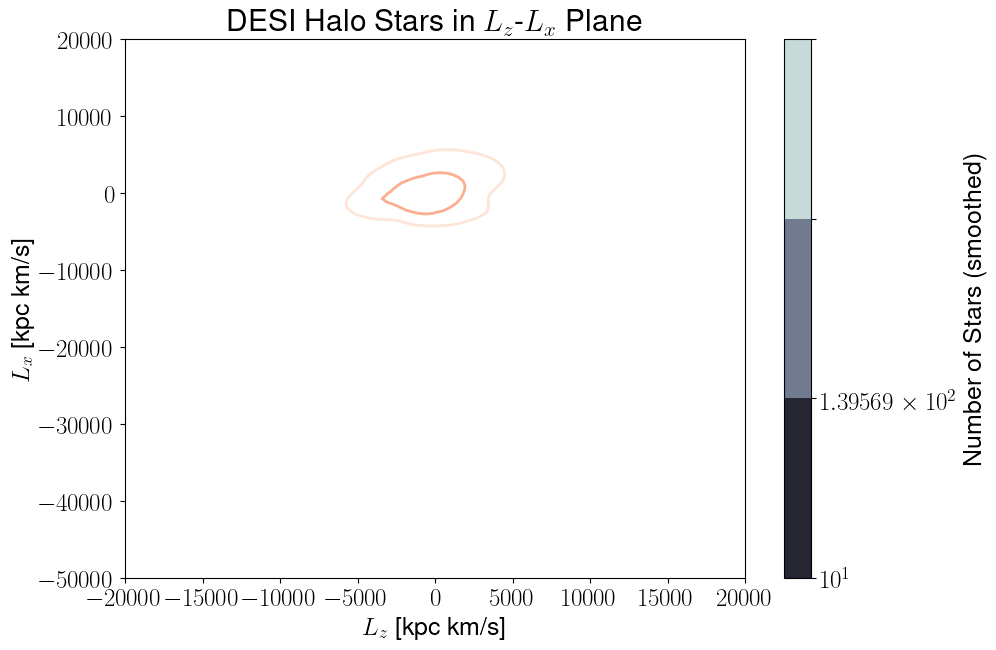

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter  # if you don't want scipy, see note below

# --- settings (match your hexbin extent) ---
xmin, xmax, ymin, ymax = -20000, 20000, -50000, 20000
xbins, ybins = 120, 120          # increase for smoother grid; ~4x your gridsize=30 feel
sigma = 1.5                      # smoothing strength (try 1.0–3.0)

# --- 2D histogram on a grid ---
H, xedges, yedges = np.histogram2d(
    desi_halo_stars["lz"],
    desi_halo_stars["lx"],
    bins=[xbins, ybins],
    range=[[xmin, xmax], [ymin, ymax]],
)
H = H.T  # (ybins, xbins) so it matches meshgrid below

# --- smooth the counts ---
Hs = gaussian_filter(H, sigma=sigma)

# --- bin centers for plotting ---
xc = 0.5 * (xedges[:-1] + xedges[1:])
yc = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(xc, yc)

# --- log-spaced contour levels (avoid zeros) ---
pos = Hs[Hs > 0]
vmin = 1e2#pos.min() if pos.size else 1.0
vmax = Hs.max() if Hs.size else 1.0
levels = np.logspace(np.log10(vmin), np.log10(vmax), 3)

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 7))

# cf = ax.contourf(
#     X, Y, Hs,
#     levels=levels,
#     cmap="bone",
#     norm=LogNorm(vmin=vmin, vmax=vmax),
# )
# use 4 shades of orange for contours
colors = ["#fee5d9","#fcae91","#fb6a4a","#cb181d"]  # light to dark orange
ax.contour(X, Y, Hs, levels=levels, colors=colors, linewidths=2, alpha=1)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel(r"$L_z$ [kpc km/s]")
ax.set_ylabel(r"$L_x$ [kpc km/s]")
ax.set_title("DESI Halo Stars in $L_z$-$L_x$ Plane")

cb = fig.colorbar(cf, ax=ax)
cb.set_label("Number of Stars (smoothed)")

plt.savefig(os.path.join(plots_dir, "desi_halo_stars_lz_lx_contours.png"), dpi=300)
plt.show()

In [77]:
chandra_color = 'lightpink'
xshooter_color = 'purple'

/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_64946/2953168473.py:12: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X*scale_factor, Y*scale_factor, Hs, levels=levels,


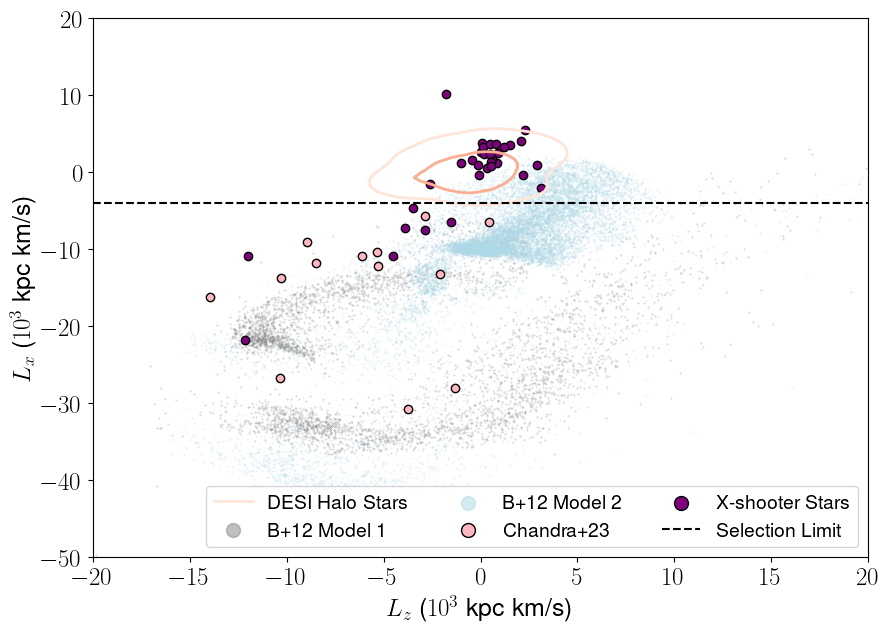

In [178]:
# all plots from here should have the same content. Stars from xshooter, chandra, 
# desi halo stars as background and the two sims.
# we will make for every plot a version with and without halo stars as background

scale_factor = 1/1e3


fig, ax = plt.subplots(figsize=(10, 7))

# MW halo
colors = ["#fee5d9","#fcae91","#fb6a4a","#cb181d"]  # light to dark orange
ax.contour(X*scale_factor, Y*scale_factor, Hs, levels=levels,
            colors=colors, linewidths=2, alpha=1,
            label='DESI Halo Stars')
# add a legend entry for the contour by just adding a line with the same color as the first contour level
ax.plot([], [], color=colors[0], label='DESI Halo Stars', linewidth=2)

# Simulations
ax.scatter(smc1_sim_lmc_masked['Lz']*scale_factor, smc1_sim_lmc_masked['Lx']*scale_factor, color='gray', label='B+12 Model 1', alpha=0.5, s=0.1)
ax.scatter(smc2_sim_lmc_masked['Lz']*scale_factor, smc2_sim_lmc_masked['Lx']*scale_factor, color='lightblue', label='B+12 Model 2', alpha=0.5, s=0.1)

# plot the non masked points in a different color
#ax.scatter(smc1_sim['Lz']*scale_factor, smc1_sim['Lx']*scale_factor, color='red', label='SMC Sim 1 Unmasked', alpha=0.5, s=0.1)
#ax.scatter(smc2_sim['Lz']*scale_factor, smc2_sim['Lx']*scale_factor, color='blue', label='SMC Sim 2 Unmasked', alpha=0.5, s=0.1)

# Chandra stars
ax.scatter(chandra['Lz']*scale_factor, chandra['Lx']*scale_factor, color=chandra_color,
            label='Chandra+23', edgecolors='k')

# X-shooter stars
ax.scatter(xshooter_merged['Lz']*scale_factor, xshooter_merged['Lx']*scale_factor, 
           color=xshooter_color, label='X-shooter Stars', edgecolors='k')

# plot selecting limit
ax.hlines(-4, -20, 20, colors='k', linestyles='--', label='Selection Limit')

ax.set_xlabel(r'$L_z$ ($10^3$ kpc km/s)')
ax.set_ylabel(r'$L_x$ ($10^3$ kpc km/s)')
ax.set_xlim(-20, 20)
ax.set_ylim(-50, 20) 
lg = plt.legend(loc='lower right', ncols=3, fontsize=14)
for handle in lg.legend_handles:
    try:
        handle.set_sizes([100])
    except AttributeError:
        pass  # some handles (like lines) don't have set_sizes
plt.savefig(os.path.join(plots_dir, 'lz_lx_comparison.png'), dpi=600)
plt.show()


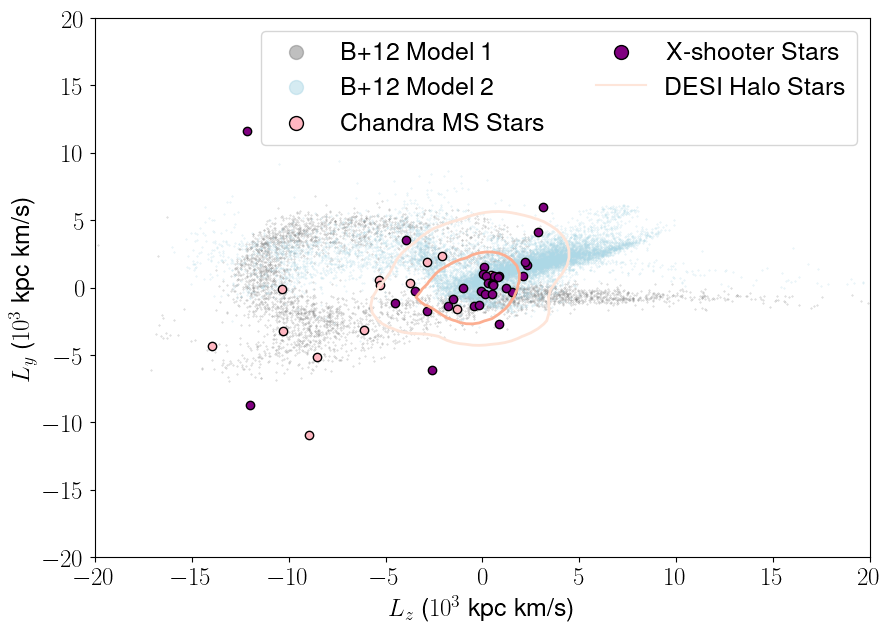

In [ ]:

scale_factor = 1/1e3


fig, ax = plt.subplots(figsize=(10, 7))

# MW halo
colors = ["#fee5d9","#fcae91","#fb6a4a","#cb181d"]  # light to dark orange
ax.contour(X*scale_factor, Y*scale_factor, Hs, levels=levels, colors=colors, linewidths=2, alpha=1)

# Simulations
ax.scatter(smc1_sim_lmc_masked['Lz']*scale_factor, smc1_sim_lmc_masked['Ly']*scale_factor,
            color='gray', label='B+12 Model 1', alpha=0.5, s=0.1)
ax.scatter(smc2_sim_lmc_masked['Lz']*scale_factor, smc2_sim_lmc_masked['Ly']*scale_factor,
            color='lightblue', label='B+12 Model 2', alpha=0.5, s=0.1)

# plot the non masked points in a different color
#ax.scatter(smc1_sim['Lz']*scale_factor, smc1_sim['Ly']*scale_factor, color='red', label='SMC Sim 1 Unmasked', alpha=0.5, s=0.1)
#ax.scatter(smc2_sim['Lz']*scale_factor, smc2_sim['Ly']*scale_factor, color='blue', label='SMC Sim 2 Unmasked', alpha=0.5, s=0.1)
# Chandra stars
ax.scatter(chandra['Lz']*scale_factor, chandra['Ly']*scale_factor, color=chandra_color, 
           label='Chandra+23', edgecolors='k')

# X-shooter stars
ax.scatter(xshooter_merged['Lz']*scale_factor, xshooter_merged['Ly']*scale_factor,
            color=xshooter_color, label='X-shooter Stars', edgecolors='k')

ax.set_xlabel(r'$L_z$ ($10^3$ kpc km/s)')
ax.set_ylabel(r'$L_y$ ($10^3$ kpc km/s)')
ax.set_xlim(-20, 20)
ax.set_ylim(-20, 20) 
# add a line in the same color as the contourplot to add it to the legend
ax.plot([], [], color=colors[0], label='DESI Halo Stars')

lg = plt.legend(loc='upper right', ncol=2)
for handle in lg.legend_handles:
    try:
        handle.set_sizes([100])
    except AttributeError:
        pass  # some handles (like lines) don't have set_sizes
plt.savefig(os.path.join(plots_dir, 'lz_ly_comparison.png'), dpi=600)
plt.show()


# Select based on angular momentum

In [85]:
# from the previous plot objects with Lx < -4e3 kpc km/s, we will select those and plot them in a different color to see if they are more likely to be associated with the SMC simulations
xshooter_candidates = xshooter_merged[xshooter_merged['Lx'] < -4e3]
print(f"Number of X-shooter candidates with Lx < -4e3 kpc km/s: {len(xshooter_candidates)}")

Number of X-shooter candidates with Lx < -4e3 kpc km/s: 7


# Magellanic coordinate plots

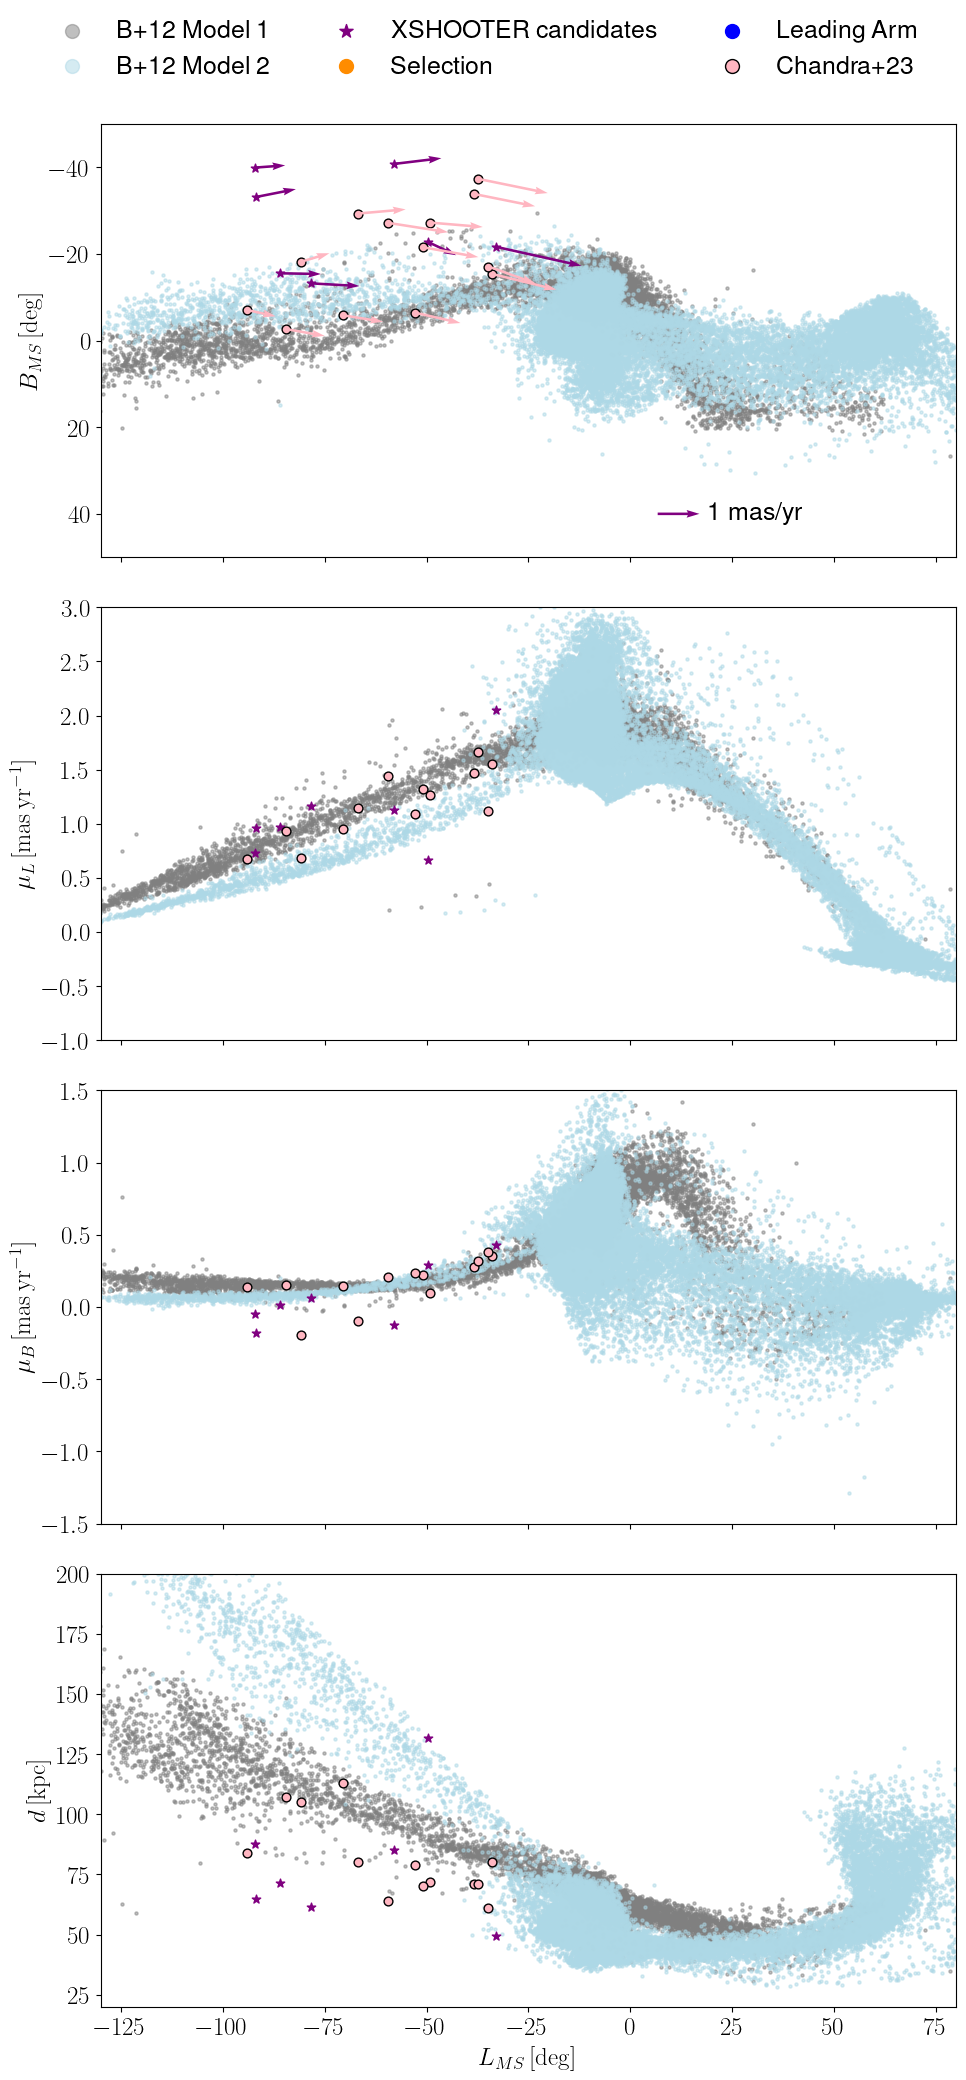

In [186]:
import matplotlib.lines as mlines

# --- NEW: choose how "long" 1 mas/yr looks in degrees on the plot
pm_scale_deg = 10.25  # deg per (mas/yr); increase for longer arrows

fig, ax = plt.subplots(4, 1, figsize=(20/2, 40/2), sharex=True)  # 5 panels now
dot_size = 5
dot_size_sel = 20

color_selection = 'darkorange'
color_all = 'k'
color_leading = 'blue'
color_xshooter = 'purple'

x = np.linspace(-130, 80, 100)

# Panel 0: same (L,B) map with highlighted subsets
#ax[0].scatter(giants['L_stream'], giants['B_stream'], s=dot_size, c=color_all, alpha=0.1)
#ax[0].scatter(trailing_arm['L_stream'], trailing_arm['B_stream'], s=dot_size_sel, c=color_selection)
#ax[0].scatter(leading_arm['L_stream'], leading_arm['B_stream'], s=dot_size_sel*2, c=color_leading, label='Leading Arm')


# --- NEW Panel 1: (L,B) with proper-motion vectors ---
# add sims
ax[0].scatter(smc1_sim['L_stream'], smc1_sim['B_stream'], s=dot_size, color='gray', label='B+12 Model 1', alpha=0.5)
ax[0].scatter(smc2_sim['L_stream'], smc2_sim['B_stream'], s=dot_size, color='lightblue', label='B+12 Model 2', alpha=0.5)

# light background points
ax[0].scatter(xshooter_candidates['L_stream'], xshooter_candidates['B_stream'],
               s=dot_size_sel*2, c=color_xshooter, label='XSHOOTER candidates', marker='*')


# quiver for xshooter observed stars
q_xshooter = ax[0].quiver(
    xshooter_candidates['L_stream'], xshooter_candidates['B_stream'],
    pm_scale_deg*xshooter_candidates['pm_l'], pm_scale_deg*xshooter_candidates['pm_b'],
    angles='xy', scale_units='xy', scale=1, width=0.003, color=color_xshooter
)

# legend proxies (quiver doesn't show in legend nicely)
ax[0].scatter([], [], c=color_selection, label='Selection')
ax[0].scatter([], [], c=color_leading, s=dot_size_sel*2, label='Leading Arm')

# same sky limits as panel 0
ax[0].set_xlim(-130, 80)
ax[0].set_ylim(-50, 50)
ax[0].set_ylabel(r'$B_{MS} \,[\mathrm{deg}]$')
#ax[1].set_title(f'Proper-motion vectors on (L,B) — scale: 1 mas/yr = {pm_scale_deg:.2f} deg')
#ax[1].legend(loc='best')

# scale key: an arrow of 1 mas/yr in length
ax[0].quiverkey(q_xshooter, 0.7, 0.10, pm_scale_deg*1.0, r'1 mas/yr', labelpos='E', coordinates='axes')

# add chandra stars to the same panel
ax[0].scatter(chandra['L_stream'], chandra['B_stream'], s=dot_size_sel*2,
               c=chandra_color, label='Chandra+23', edgecolors='k')
# add quiver for chandra stars
q_chandra = ax[0].quiver(
    chandra['L_stream'], chandra['B_stream'],
    pm_scale_deg*chandra['pm_l'], pm_scale_deg*chandra['pm_b'],
    angles='xy', scale_units='xy', scale=1, width=0.003, color=chandra_color
)

# add quiver key for chandra stars
#ax[0].quiverkey(q_chandra, 0.92, 0.05, pm_scale_deg*1.0, r'1 mas/yr', labelpos='E', coordinates='axes')


ax[0].set_ylim(50, -50)
ax[0].set_xlim(-130, 80)
#ax[0].legend(loc='lower left')
# put the legend outside the plot at the top
# --- Create a single legend for the whole figure ---
handles, labels = ax[0].get_legend_handles_labels()
# # make the markers in the legend bigger
# for handle in handles:
#     try:
#         handle.set_sizes([100])
#     except AttributeError:
#         pass  # some handles (like lines) don't have set_sizes

lg = fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),  # slightly above the figure
    ncol=3,
    frameon=False
)
for handle in lg.legend_handles:
    try:
        handle.set_sizes([100])
    except AttributeError:
        pass

# leave room at the top for legend
plt.tight_layout(rect=[0, 0, 1, 0.97])


# Panel 2: μ_L vs L (shifted from [1] -> [2])
# sims
ax[1].scatter(smc1_sim['L_stream'], smc1_sim['pm_l'], s=dot_size, color='gray', label='B+12 Model 1', alpha=0.5)
ax[1].scatter(smc2_sim['L_stream'], smc2_sim['pm_l'], s=dot_size, color='lightblue', label='B+12 Model 2', alpha=0.5)
# x-shooter
ax[1].scatter(xshooter_candidates['L_stream'], xshooter_candidates['pm_l'], s=dot_size_sel*2, c=color_xshooter, label='Observed with XSHOOTER', marker='*')
# chandra
ax[1].scatter(chandra['L_stream'], chandra['pm_l'], s=dot_size_sel*2, c=chandra_color, label='Chandra+23', edgecolors='k')
# ax[1].hlines(0, -130, 80, 'r', '--', label='limit')
# ax[1].fill_between(x, -1, 0.5, color='gray', alpha=0.3)
ax[1].set_ylabel(r'$\mu_{L} \,[\mathrm{mas\,yr^{-1}}]$')
ax[1].set_ylim(-1, 3)

# Panel 3: μ_B vs L (shifted from [2] -> [3])
# sims
ax[2].scatter(smc1_sim['L_stream'], smc1_sim['pm_b'], s=dot_size,
               color='gray', label='B+12 Model 1', alpha=0.5)
ax[2].scatter(smc2_sim['L_stream'], smc2_sim['pm_b'], s=dot_size, 
              color='lightblue', label='B+12 Model 2', alpha=0.5)
# x-shooter
ax[2].scatter(xshooter_candidates['L_stream'], xshooter_candidates['pm_b'], s=dot_size_sel*2, c=color_xshooter, label='Observed with XSHOOTER', marker='*')
# chandra
ax[2].scatter(chandra['L_stream'], chandra['pm_b'], s=dot_size_sel*2, c=chandra_color, label='Chandra+23', edgecolors='k')


# ax[2].hlines(0.5, -130, 80, 'r', '--', label='limit')
# ax[2].hlines(-0.5, -130, 80, 'r', '--', label='limit')
# ax[2].fill_between(x, -0.5, 0.5, color='gray', alpha=0.3)
ax[2].set_ylabel(r'$\mu_{B} \,[\mathrm{mas\,yr^{-1}}]$')
ax[2].set_ylim(-1.5, 1.5)

# Panel 4: distance vs L (shifted from [3] -> [4])
# sims
ax[3].scatter(smc1_sim['L_stream'], smc1_sim['distance'], s=dot_size, color='gray',
               label='B+12 Model 1', alpha=0.5)
ax[3].scatter(smc2_sim['L_stream'], smc2_sim['distance'], s=dot_size, color='lightblue', 
              label='B+12 Model 2', alpha=0.5)
# x-shooter
ax[3].scatter(xshooter_candidates['L_stream'], xshooter_candidates['dist_pc_p50']/1000, s=dot_size_sel*2, c=color_xshooter, label='Observed with XSHOOTER', marker='*')
# chandra
ax[3].scatter(chandra['L_stream'], chandra['distance'], s=dot_size_sel*2, c=chandra_color, label='Chandra+23', edgecolors='k')
ax[3].set_ylim(20, 200)
ax[3].set_ylabel(r'$d \,[\mathrm{kpc}]$')
ax[3].set_xlabel(r'$L_{MS} \,[\mathrm{deg}]$')
#ax[4].legend(loc='best')

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'xshooter_proper_motions.png'), dpi=900, bbox_inches='tight')
plt.show()


In [185]:
# import os
# import numpy as np
# import matplotlib.pyplot as plt

# # --- keep your settings ---
# pm_scale_deg = 10.25  # deg per (mas/yr)

# dot_size = 5
# dot_size_sel = 20

# color_selection = 'darkorange'
# color_all = 'k'
# color_leading = 'blue'
# color_xshooter = 'purple'

# x = np.linspace(-130, 80, 100)

def style_legend_markers(leg, size=100):
    """Make scatter markers in the legend larger (safe for non-scatter handles)."""
    for h in leg.legend_handles:
        try:
            h.set_sizes([size])
        except Exception:
            pass

# -----------------------
# Panel 1 (your ax[0]): (L,B) + PM vectors
# -----------------------
def plot_panel_lb(ax):
    ax.scatter(smc1_sim['L_stream'], smc1_sim['B_stream'], s=dot_size, color='gray',
               label='B+12 Model 1', alpha=0.5)
    ax.scatter(smc2_sim['L_stream'], smc2_sim['B_stream'], s=dot_size, color='lightblue',
               label='B+12 Model 2', alpha=0.5)

    ax.scatter(xshooter_candidates['L_stream'], xshooter_candidates['B_stream'],
               s=dot_size_sel*2, c=color_xshooter, label='XSHOOTER candidates', marker='*')

    q_xshooter = ax.quiver(
        xshooter_candidates['L_stream'], xshooter_candidates['B_stream'],
        pm_scale_deg*xshooter_candidates['pm_l'], pm_scale_deg*xshooter_candidates['pm_b'],
        angles='xy', scale_units='xy', scale=1, width=0.003, color=color_xshooter
    )

    # legend proxies you had
    ax.scatter([], [], c=color_selection, label='Selection')
    ax.scatter([], [], c=color_leading, s=dot_size_sel*2, label='Leading Arm')

    ax.quiverkey(q_xshooter, 0.7, 0.10, pm_scale_deg*1.0, r'1 mas/yr',
                 labelpos='E', coordinates='axes')

    ax.scatter(chandra['L_stream'], chandra['B_stream'], s=dot_size_sel*2,
               c=chandra_color, label='Chandra+23', edgecolors='k')
    ax.quiver(
        chandra['L_stream'], chandra['B_stream'],
        pm_scale_deg*chandra['pm_l'], pm_scale_deg*chandra['pm_b'],
        angles='xy', scale_units='xy', scale=1, width=0.003, color=chandra_color
    )

    ax.set_xlim(-130, 80)
    ax.set_ylim(50, -50)  # your inverted B axis
    ax.set_ylabel(r'$B_{MS} \,[\mathrm{deg}]$')


# -----------------------
# Panel 2 (your ax[1]): pm_l vs L
# -----------------------
def plot_panel_pml(ax):
    ax.scatter(smc1_sim['L_stream'], smc1_sim['pm_l'], s=dot_size, color='gray',
               label='B+12 Model 1', alpha=0.5)
    ax.scatter(smc2_sim['L_stream'], smc2_sim['pm_l'], s=dot_size, color='lightblue',
               label='B+12 Model 2', alpha=0.5)

    ax.scatter(xshooter_candidates['L_stream'], xshooter_candidates['pm_l'],
               s=dot_size_sel*2, c=color_xshooter, label='Observed with XSHOOTER', marker='*')

    ax.scatter(chandra['L_stream'], chandra['pm_l'], s=dot_size_sel*2,
               c=chandra_color, label='Chandra+23', edgecolors='k')

    ax.set_ylabel(r'$\mu_{L} \,[\mathrm{mas\,yr^{-1}}]$')
    ax.set_ylim(-1, 3)
    ax.set_xlim(-130, 80)


# -----------------------
# Panel 3 (your ax[2]): pm_b vs L
# -----------------------
def plot_panel_pmb(ax):
    ax.scatter(smc1_sim['L_stream'], smc1_sim['pm_b'], s=dot_size, color='gray',
               label='B+12 Model 1', alpha=0.5)
    ax.scatter(smc2_sim['L_stream'], smc2_sim['pm_b'], s=dot_size, color='lightblue',
               label='B+12 Model 2', alpha=0.5)

    ax.scatter(xshooter_candidates['L_stream'], xshooter_candidates['pm_b'],
               s=dot_size_sel*2, c=color_xshooter, label='Observed with XSHOOTER', marker='*')

    ax.scatter(chandra['L_stream'], chandra['pm_b'], s=dot_size_sel*2,
               c=chandra_color, label='Chandra+23', edgecolors='k')

    ax.set_ylabel(r'$\mu_{B} \,[\mathrm{mas\,yr^{-1}}]$')
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlim(-130, 80)


# -----------------------
# Panel 4 (your ax[3]): distance vs L
# -----------------------
def plot_panel_dist(ax):
    ax.scatter(smc1_sim['L_stream'], smc1_sim['distance'], s=dot_size, color='gray',
               label='B+12 Model 1', alpha=0.5)
    ax.scatter(smc2_sim['L_stream'], smc2_sim['distance'], s=dot_size, color='lightblue',
               label='B+12 Model 2', alpha=0.5)

    ax.scatter(xshooter_candidates['L_stream'], xshooter_candidates['dist_pc_p50']/1000,
               s=dot_size_sel*2, c=color_xshooter, label='Observed with XSHOOTER', marker='*')

    ax.scatter(chandra['L_stream'], chandra['distance'], s=dot_size_sel*2,
               c=chandra_color, label='Chandra+23', edgecolors='k')

    ax.set_ylim(20, 200)
    ax.set_xlim(-130, 80)
    ax.set_ylabel(r'$d \,[\mathrm{kpc}]$')
    ax.set_xlabel(r'$L_{MS} \,[\mathrm{deg}]$')


# -----------------------
# Make + save each one
# -----------------------
panel_specs = [
    ("panel_lb",   plot_panel_lb,   dict(figsize=(20/2, 10/2))),
    ("panel_pml",  plot_panel_pml,  dict(figsize=(20/2, 10/2))),
    ("panel_pmb",  plot_panel_pmb,  dict(figsize=(20/2, 10/2))),
    ("panel_dist", plot_panel_dist, dict(figsize=(20/2, 10/2))),
]

for name, fn, fig_kw in panel_specs:
    fig, ax = plt.subplots(1, 1, **fig_kw)
    fn(ax)

    # per-figure legend (instead of the shared fig.legend)
    leg = ax.legend(loc='best', frameon=False)
    if leg is not None:
        style_legend_markers(leg, size=100)

    fig.tight_layout()
    fig.savefig(os.path.join(plots_dir, f'xshooter_{name}.png'), dpi=900)
    plt.close(fig)  # avoids piling up open figures

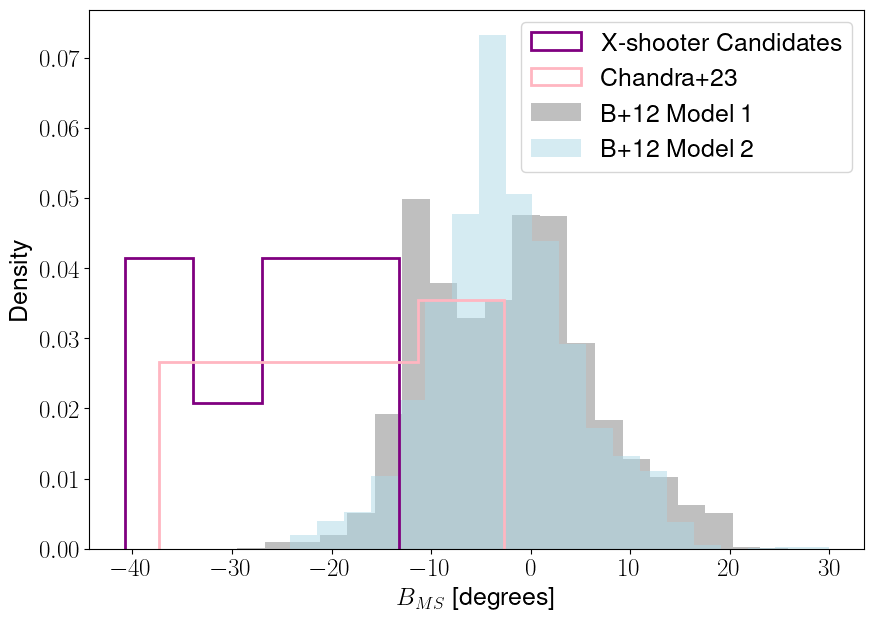

In [164]:
# histogram of B for the xshooter candidates
fig, ax = plt.subplots(figsize=(10, 7))
ax.hist(xshooter_candidates['B_stream'], bins=4, color=color_xshooter,
         alpha=1, histtype='step',
         # increase the line width of the histogram
        linewidth=2,    
         density=True, label='X-shooter Candidates')

# also put the histogram of the B values for the chandra stars
ax.hist(chandra['B_stream'], bins=4, color=chandra_color,
        density=True, label='Chandra+23',
        linewidth=2,
         alpha=1, histtype='step')

# sims but only with L < 25
ax.hist(smc1_sim_lmc_masked[smc1_sim_lmc_masked['L_stream'] < 25]['B_stream'], bins=20,
        density=True,
         color='gray', alpha=0.5, label='B+12 Model 1')
ax.hist(smc2_sim_lmc_masked[smc2_sim_lmc_masked['L_stream'] < 25]['B_stream'], bins=20, 
        density=True,
        color='lightblue', alpha=0.5, label='B+12 Model 2')
ax.set_xlabel(r'$B_{MS}$ [degrees]')
ax.set_ylabel('Density')
plt.legend()
plt.savefig(os.path.join(plots_dir, 'xshooter_candidates_b_histogram.png'), dpi=300)
plt.show()

In [118]:
# compute the average offset in B between the xshooter candidates and the sims, we will do this by computing the average B value for the candidates and the average B value for the sims in the same L range, and then taking the difference
xshooter_b_mean = xshooter_candidates['B_stream'].mean()
sim1_b_mean = smc1_sim_lmc_masked[(smc1_sim_lmc_masked['L_stream'] < 25) & (smc1_sim_lmc_masked['L_stream'] > -130)]['B_stream'].mean()
sim2_b_mean = smc2_sim_lmc_masked[(smc2_sim_lmc_masked['L_stream'] < 25) & (smc2_sim_lmc_masked['L_stream'] > -130)]['B_stream'].mean()
print(f"Average B for X-shooter candidates: {xshooter_b_mean:.2f} degrees")
print(f"Average B for B+12 Model 1 (L between -130 and 25): {sim1_b_mean:.2f} degrees")
print(f"Average B for B+12 Model 2 (L between -130 and 25): {sim2_b_mean:.2f} degrees")
print(f"Offset in B between X-shooter candidates and B+12 Model 1: {xshooter_b_mean - sim1_b_mean:.2f} degrees")
print(f"Offset in B between X-shooter candidates and B+12 Model 2: {xshooter_b_mean - sim2_b_mean:.2f} degrees")

Average B for X-shooter candidates: -26.71 degrees
Average B for B+12 Model 1 (L between -130 and 25): -2.51 degrees
Average B for B+12 Model 2 (L between -130 and 25): -2.63 degrees
Offset in B between X-shooter candidates and B+12 Model 1: -24.20 degrees
Offset in B between X-shooter candidates and B+12 Model 2: -24.08 degrees


In [ ]:
# compute the average offset but now for chandra stars
chandra_b_mean = chandra['B_stream'].mean()
print(f"Average B for Chandra+23: {chandra_b_mean:.2f} degrees")
print(f"Offset in B between Chandra+23 and B+12 Model 1: {chandra_b_mean - sim1_b_mean:.2f} degrees")
print(f"Offset in B between Chandra+23 and B+12 Model 2: {chandra_b_mean - sim2_b_mean:.2f} degrees")



Average B for Chandra MS stars: -19.17 degrees
Offset in B between Chandra MS stars and B+12 Model 1: -16.66 degrees
Offset in B between Chandra MS stars and B+12 Model 2: -16.54 degrees


In [120]:
# now if we agregate chandra and xshooter candidates together, what is the average B and the offset with the sims?
combined_b_mean = np.concatenate([xshooter_candidates['B_stream'], chandra['B_stream']]).mean()
print(f"Average B for combined X-shooter candidates and Chandra MS stars: {combined_b_mean:.2f} degrees")
print(f"Offset in B between combined sample and B+12 Model 1: {combined_b_mean - sim1_b_mean:.2f} degrees")
print(f"Offset in B between combined sample and B+12 Model 2: {combined_b_mean - sim2_b_mean:.2f} degrees")

Average B for combined X-shooter candidates and Chandra MS stars: -21.81 degrees
Offset in B between combined sample and B+12 Model 1: -19.30 degrees
Offset in B between combined sample and B+12 Model 2: -19.18 degrees


In [165]:
# now the offset in distancem, for this we will compute the moving average distance as a function of L for the sims,
#  and then compute the average distance for the xshooter candidates and chandra stars to that moving average
xshooter_candidates['distance'] = xshooter_candidates['dist_pc_p50']/1000  # convert from pc to kpc
# compute moving mean distance for the sims as a function of L, we will use a window of 20 degrees in L
def moving_average_distance(sim, window=10):
    L_bins = np.arange(-130, 80, window)
    L_centers = 0.5 * (L_bins[:-1] + L_bins[1:])
    distance_means = []
    for i in range(len(L_bins)-1):
        mask = (sim['L_stream'] >= L_bins[i]) & (sim['L_stream'] < L_bins[i+1])
        if np.any(mask):
            distance_means.append(sim[mask]['distance'].mean())
        else:
            distance_means.append(np.nan)  # or some other placeholder for empty bins
    return L_centers, np.array(distance_means)

L_centers1, distance_means1 = moving_average_distance(smc1_sim_lmc_masked)
L_centers2, distance_means2 = moving_average_distance(smc2_sim_lmc_masked)

# now compute the average distance for the xshooter candidates and chandra stars to that moving average,
#  we will do this by interpolating the moving average distance at the L values of the candidates and stars,
#  and then computing the average absolute difference
from scipy.interpolate import interp1d
def average_distance_offset(candidates, L_centers, distance_means):
    # create an interpolation function for the moving average distance
    interp_func = interp1d(L_centers, distance_means, bounds_error=False, fill_value=np.nan)
    # interpolate the moving average distance at the L values of the candidates
    interpolated_distances = interp_func(candidates['L_stream'])
    # compute the absolute difference between the candidates' distances and the interpolated distances
    distance_offsets = np.abs(candidates['distance'] - interpolated_distances)
    # return the average offset, ignoring NaN values
    return np.nanmean(distance_offsets)

offset_xshooter_sim1 = average_distance_offset(xshooter_candidates, L_centers1, distance_means1)
offset_xshooter_sim2 = average_distance_offset(xshooter_candidates, L_centers2, distance_means2)
offset_chandra_sim1 = average_distance_offset(chandra, L_centers1, distance_means1)
offset_chandra_sim2 = average_distance_offset(chandra, L_centers2, distance_means2)  

# now for the combined sample of xshooter and chandra data in L and distance
combined_sample = Table(np.concatenate([xshooter_candidates[['L_stream', 'distance']], chandra[['L_stream', 'distance']]]))
offset_combined_sim1 = average_distance_offset(combined_sample, L_centers1, distance_means1)
offset_combined_sim2 = average_distance_offset(combined_sample, L_centers2, distance_means2)

print(f"Average distance offset between X-shooter candidates and B+12 Model 1: {offset_xshooter_sim1:.2f} kpc")
print(f"Average distance offset between X-shooter candidates and B+12 Model 2: {offset_xshooter_sim2:.2f} kpc")
print(f"Average distance offset between Chandra MS stars and B+12 Model 1: {offset_chandra_sim1:.2f} kpc")
print(f"Average distance offset between Chandra MS stars and B+12 Model 2: {offset_chandra_sim2:.2f} kpc")
print(f"Average distance offset between combined sample and B+12 Model 1: {offset_combined_sim1:.2f} kpc")
print(f"Average distance offset between combined sample and B+12 Model 2: {offset_combined_sim2:.2f} kpc")

Average distance offset between X-shooter candidates and B+12 Model 1: 38.27 kpc
Average distance offset between X-shooter candidates and B+12 Model 2: 68.50 kpc
Average distance offset between Chandra MS stars and B+12 Model 1: 18.87 kpc
Average distance offset between Chandra MS stars and B+12 Model 2: 47.60 kpc
Average distance offset between combined sample and B+12 Model 1: 25.66 kpc
Average distance offset between combined sample and B+12 Model 2: 54.92 kpc


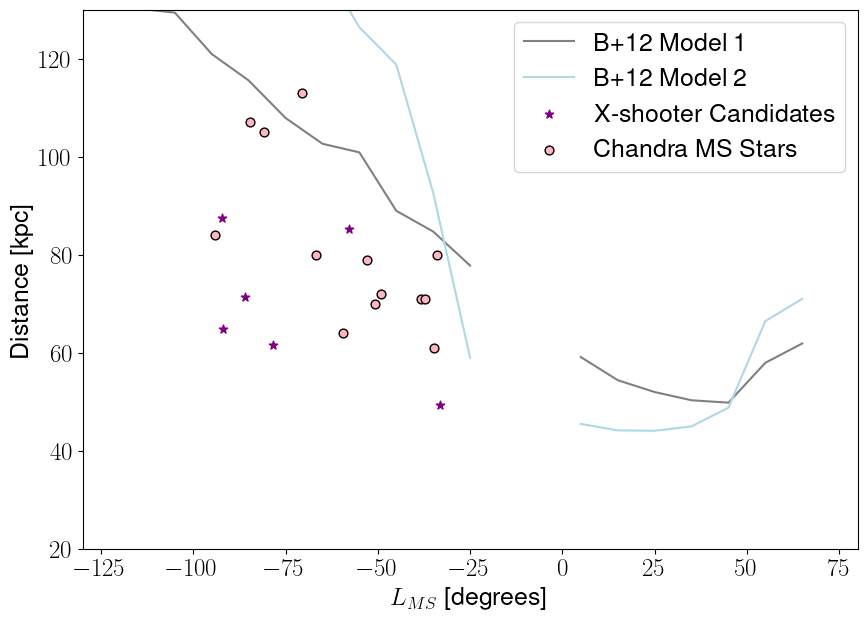

In [166]:
# plot the moving average distance as a function of L for the sims, and the candidates and stars on top
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(L_centers1, distance_means1, label='B+12 Model 1', color='gray')
ax.plot(L_centers2, distance_means2, label='B+12 Model 2', color='lightblue')
ax.scatter(xshooter_candidates['L_stream'], xshooter_candidates['distance'], s=dot_size_sel*2, c=color_xshooter, label='X-shooter Candidates', marker='*')
ax.scatter(chandra['L_stream'], chandra['distance'], s=dot_size_sel*2, c=chandra_color, label='Chandra MS Stars', edgecolors='k')
ax.set_xlabel(r'$L_{MS}$ [degrees]')
ax.set_ylabel(r'Distance [kpc]')
ax.set_xlim(-130, 80)
ax.set_ylim(20, 130)
plt.legend()
plt.show()

/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_64946/2419794513.py:15: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(chandra['L_stream'], chandra_diff_sim2, s=dot_size_sel*2, c=chandra_color, label='Chandra vs B+12 Model 2', edgecolors='k', marker='x')


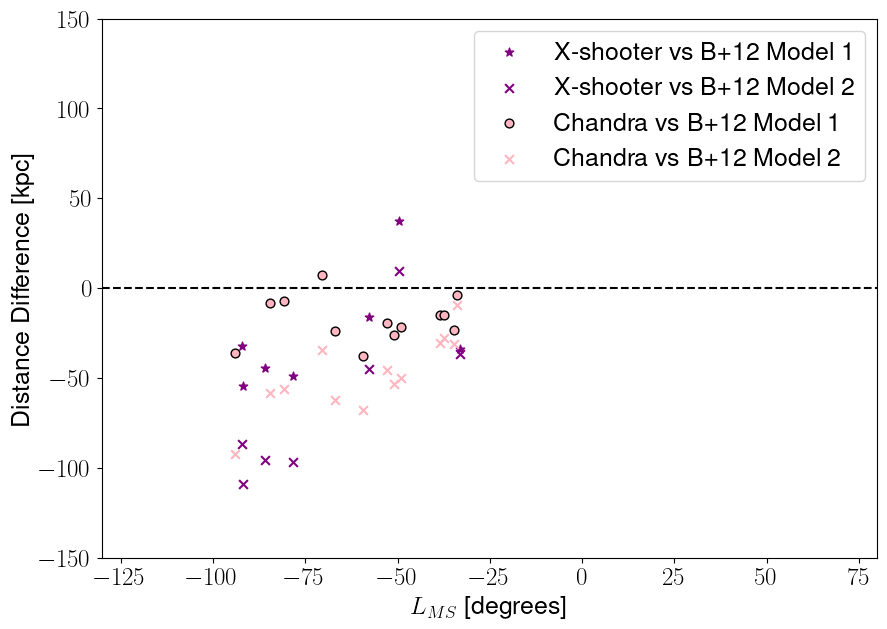

In [167]:
# plot the difference in distance between the candidates and the sims as a function of L
fig, ax = plt.subplots(figsize=(10, 7))
# compute the distance difference for xshooter candidates and sims
def distance_difference(candidates, L_centers, distance_means):
    interp_func = interp1d(L_centers, distance_means, bounds_error=False, fill_value=np.nan)
    interpolated_distances = interp_func(candidates['L_stream'])
    return candidates['distance'] - interpolated_distances
xshooter_diff_sim1 = distance_difference(xshooter_candidates, L_centers1, distance_means1)
xshooter_diff_sim2 = distance_difference(xshooter_candidates, L_centers2, distance_means2)
chandra_diff_sim1 = distance_difference(chandra, L_centers1, distance_means1)
chandra_diff_sim2 = distance_difference(chandra, L_centers2, distance_means2)
ax.scatter(xshooter_candidates['L_stream'], xshooter_diff_sim1, s=dot_size_sel*2, c=color_xshooter, label='X-shooter vs B+12 Model 1', marker='*')
ax.scatter(xshooter_candidates['L_stream'], xshooter_diff_sim2, s=dot_size_sel*2, c=color_xshooter, label='X-shooter vs B+12 Model 2', marker='x')
ax.scatter(chandra['L_stream'], chandra_diff_sim1, s=dot_size_sel*2, c=chandra_color, label='Chandra vs B+12 Model 1', edgecolors='k')
ax.scatter(chandra['L_stream'], chandra_diff_sim2, s=dot_size_sel*2, c=chandra_color, label='Chandra vs B+12 Model 2', edgecolors='k', marker='x')
ax.axhline(0, color='k', linestyle='--')
ax.set_xlabel(r'$L_{MS}$ [degrees]')
ax.set_ylabel(r'Distance Difference [kpc]')
ax.set_xlim(-130, 80)
ax.set_ylim(-150, 150)
plt.legend()
plt.show()

In [139]:
xshooter_candidates

OBJECT,arm,Teff,logg,feh,alpha,vsini,vel,hel_vel,vel_err,vel_skewness,vel_kurtosis,teff_err,logg_err,feh_err,alpha_err,minimize_success,bad_hessian,chisq,logl,npix,chisq_red,filename,source_id,a_image_g,a_image_i,a_image_r,a_image_z,b_image_g,b_image_i,b_image_r,b_image_z,ccdnum_g,ccdnum_i,ccdnum_r,ccdnum_z,class_star_g,class_star_i,class_star_r,class_star_z,dec,ebv,expnum_g,expnum_i,expnum_r,expnum_z,exptime_g,exptime_i,exptime_r,exptime_z,extended_class_g,extended_class_i,extended_class_r,extended_class_z,extinction_g,extinction_i,extinction_r,extinction_z,flags_g,flags_i,flags_r,flags_z,hpx2048,htm9,mag_auto_g,mag_auto_i,mag_auto_r,mag_auto_z,mag_psf_g,mag_psf_i,mag_psf_r,mag_psf_z,magerr_auto_g,magerr_auto_i,magerr_auto_r,magerr_auto_z,magerr_psf_g,magerr_psf_i,magerr_psf_r,magerr_psf_z,nepochs_g,nepochs_i,nepochs_r,nepochs_z,nest4096,quick_object_id,ra,random_id,ring256,spread_model_g,spread_model_i,spread_model_r,spread_model_z,spreaderr_model_g,spreaderr_model_i,spreaderr_model_r,spreaderr_model_z,t_eff_g,t_eff_i,t_eff_r,t_eff_z,theta_image_g,theta_image_i,theta_image_r,theta_image_z,wavg_flags_g,wavg_flags_i,wavg_flags_r,wavg_flags_z,wavg_mag_auto_g,wavg_mag_auto_i,wavg_mag_auto_r,wavg_mag_auto_z,DECam_g,DECam_i,DECam_r,DECam_z,wavg_magerr_auto_g,wavg_magerr_auto_i,wavg_magerr_auto_r,wavg_magerr_auto_z,DECam_g_ERR,DECam_i_ERR,DECam_r_ERR,DECam_z_ERR,wavg_magrms_auto_g,wavg_magrms_auto_i,wavg_magrms_auto_r,wavg_magrms_auto_z,wavg_magrms_psf_g,wavg_magrms_psf_i,wavg_magrms_psf_r,wavg_magrms_psf_z,wavg_spread_model_g,wavg_spread_model_i,wavg_spread_model_r,wavg_spread_model_z,wavg_spreaderr_model_g,wavg_spreaderr_model_i,wavg_spreaderr_model_r,wavg_spreaderr_model_z,wavg_spreadrms_model_g,wavg_spreadrms_model_i,wavg_spreadrms_model_r,wavg_spreadrms_model_z,mjd_obs,elon,elat,glon,glat,on_sky_distance_arcsec,SOURCEID,CUEVENTID,FRAMESETID,RA2000,DEC2000,L,B,LAMBDA,ETA,PRIORSEC,YMJPNT,YMJPNTERR,JMHPNT,JMHPNTERR,HMKSPNT,HMKSPNTERR,JMKSPNT,JMKSPNTERR,YMJEXT,YMJEXTERR,JMHEXT,JMHEXTERR,HMKSEXT,HMKSEXTERR,JMKSEXT,JMKSEXTERR,MERGEDCLASSSTAT,MERGEDCLASS,PSTAR,PGALAXY,PNOISE,PSATURATED,EBV,AY,AJ,AH,AKS,YMJD,YPETROMAG,YPETROMAGERR,YPSFMAG,YPSFMAGERR,YSERMAG2D,YSERMAG2DERR,YAPERMAG3,YAPERMAG3ERR,YAPERMAG4,YAPERMAG4ERR,YAPERMAG6,YAPERMAG6ERR,YAPERMAGNOAPERCORR3,YAPERMAGNOAPERCORR4,YAPERMAGNOAPERCORR6,YHLCORSMJRADAS,YGAUSIG,YELL,YPA,YERRBITS,YAVERAGECONF,YCLASS,YCLASSSTAT,YPPERRBITS,YSEQNUM,YXI,YETA,JMJD,JPETROMAG,JPETROMAGERR,JPSFMAG,JPSFMAGERR,JSERMAG2D,JSERMAG2DERR,VISTA_J,2MASS_J_ERR,JAPERMAG4,JAPERMAG4ERR,JAPERMAG6,JAPERMAG6ERR,JAPERMAGNOAPERCORR3,JAPERMAGNOAPERCORR4,JAPERMAGNOAPERCORR6,JHLCORSMJRADAS,JGAUSIG,JELL,JPA,JERRBITS,JAVERAGECONF,JCLASS,JCLASSSTAT,JPPERRBITS,JSEQNUM,JXI,JETA,HMJD,HPETROMAG,HPETROMAGERR,HPSFMAG,HPSFMAGERR,HSERMAG2D,HSERMAG2DERR,VISTA_H,2MASS_H_ERR,HAPERMAG4,HAPERMAG4ERR,HAPERMAG6,HAPERMAG6ERR,HAPERMAGNOAPERCORR3,HAPERMAGNOAPERCORR4,HAPERMAGNOAPERCORR6,HHLCORSMJRADAS,HGAUSIG,HELL,HPA,HERRBITS,HAVERAGECONF,HCLASS,HCLASSSTAT,HPPERRBITS,HSEQNUM,HXI,HETA,KSMJD,KSPETROMAG,KSPETROMAGERR,KSPSFMAG,KSPSFMAGERR,KSSERMAG2D,KSSERMAG2DERR,VISTA_Ks,2MASS_Ks_ERR,KSAPERMAG4,KSAPERMAG4ERR,KSAPERMAG6,KSAPERMAG6ERR,KSAPERMAGNOAPERCORR3,KSAPERMAGNOAPERCORR4,KSAPERMAGNOAPERCORR6,KSHLCORSMJRADAS,KSGAUSIG,KSELL,KSPA,KSERRBITS,KSAVERAGECONF,KSCLASS,KSCLASSSTAT,KSPPERRBITS,KSSEQNUM,KSXI,KSETA,PRIMARY_SOURCE,g_i,i_Ks,gmag,dist_1,g_ABS_1,dist_2,g_ABS_2,dist_3,g_ABS_3,dist_4,g_ABS_4,L_stream,B_stream,ra_epoch2000,dec_epoch2000,errHalfMaj,errHalfMin,errPosAng,ra_x,ra_error,dec_x,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,astrometric_n_good_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,pseudocolour,pseudocolour_error,visibility_periods_used,ruwe,duplicated_source,phot_g_mean_flux,phot_g_mean_flux_error,Gaia_G_EDR3,phot_bp_mean_flux,phot_bp_mean_flux_error,Gaia_BP_EDR3,phot_rp_mean_flux,Gaia_RP_EDR3,phot_bp_rp_ex

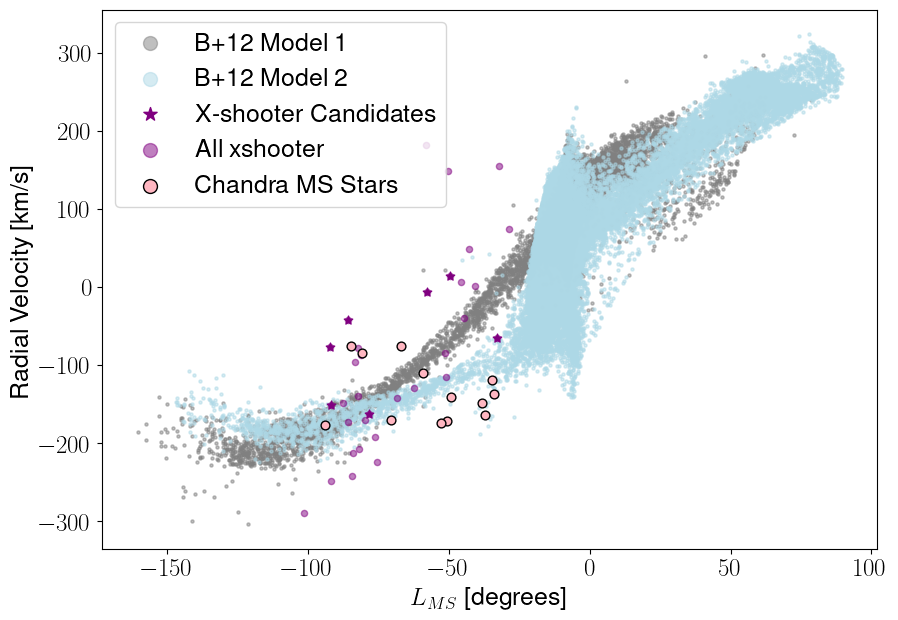

In [145]:
# radial velocity as a function of L for the candidates and stars, compared to the sims
fig, ax = plt.subplots(figsize=(10, 7))
#ax.plot(L_centers1, smc1_sim_lmc_masked.groupby(np.digitize(smc1_sim_lmc_masked['L_stream'], L_centers1))['radial_velocity'].mean(), label='B+12 Model 1', color='gray')
#x.plot(L_centers2, smc2_sim_lmc_masked.groupby(np.digitize(smc2_sim_lmc_masked['L_stream'], L_centers2))['radial_velocity'].mean(), label='B+12 Model 2', color='lightblue')
ax.scatter(smc1_sim['L_stream'], smc1_sim['radial_velocity'], s=dot_size, color='gray', label='B+12 Model 1', alpha=0.5)
ax.scatter(smc2_sim['L_stream'], smc2_sim['radial_velocity'], s=dot_size, color='lightblue', label='B+12 Model 2', alpha=0.5)
ax.scatter(xshooter_candidates['L_stream'], xshooter_candidates['hel_vel'], s=dot_size_sel*2, c=color_xshooter, label='X-shooter Candidates', marker='*')
# plot also other xshooter stars that are not candidates but have radial velocity measurements, in a different color
ax.scatter(xshooter_merged['L_stream'], 
           xshooter_merged['hel_vel'], 
           s=dot_size_sel, c=color_xshooter, label='All xshooter', alpha=0.5)
ax.scatter(chandra['L_stream'], chandra['radial_velocity'], s=dot_size_sel*2, c=chandra_color, label='Chandra MS Stars', edgecolors='k')
ax.set_xlabel(r'$L_{MS}$ [degrees]')
ax.set_ylabel(r'Radial Velocity [km/s]')
#ax.set_xlim(-130, 80)
#ax.set_ylim(-300, 300)
lg = plt.legend(loc='upper left')
for handle in lg.legend_handles:
    try:
        handle.set_sizes([100])
    except AttributeError:
        pass  # some handles (like lines) don't have set_sizes
plt.savefig(os.path.join(plots_dir, 'xshooter_candidates_radial_velocity.png'), dpi=600)
plt.show()

# Load orbits

In [158]:
lmc_m1 = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/LMC_orbit_besla2012/com_b12/LMC_model1_com.csv')
lmc_m2 = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/LMC_orbit_besla2012/com_b12/LMC_model2_com.csv')
smc_m1 = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/LMC_orbit_besla2012/com_b12/SMC_model1_com.csv')
smc_m2 = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/LMC_orbit_besla2012/com_b12/SMC_model2_com.csv')


def add_coords_orbit(orbit_table):
    coords = SkyCoord(x = orbit_table['x']*u.kpc, y = orbit_table['y']*u.kpc, z = orbit_table['z']*u.kpc,
                      v_x = orbit_table['v_x']*u.km/u.s, v_y = orbit_table['v_y']*u.km/u.s, v_z = orbit_table['v_z']*u.km/u.s,
                      frame=Galactocentric())
    stream_coords = coords.transform_to(MagellanicStreamNidever08())
    orbit_table['L_stream'] = stream_coords.L.degree
    orbit_table['B_stream'] = stream_coords.B.degree
    orbit_table['pm_l'] = stream_coords.pm_L_cosB
    orbit_table['pm_b'] = stream_coords.pm_B
    icrs_coords = coords.transform_to(ICRS())
    orbit_table['ra'] = icrs_coords.ra.degree
    orbit_table['dec'] = icrs_coords.dec.degree
    orbit_table['pm_ra'] = icrs_coords.pm_ra_cosdec
    orbit_table['pm_dec'] = icrs_coords.pm_dec
    orbit_table['distance'] = icrs_coords.distance.kpc
    orbit_table['radial_velocity'] = icrs_coords.radial_velocity.to(u.km/u.s).value
    return orbit_table

smc_m1 = add_coords_orbit(smc_m1)
smc_m2 = add_coords_orbit(smc_m2)
lmc_m1 = add_coords_orbit(lmc_m1)
lmc_m2 = add_coords_orbit(lmc_m2)


In [209]:
smc_m1

t,x,y,z,v_x,v_y,v_z,L_stream,B_stream,pm_l,pm_b,ra,dec,pm_ra,pm_dec,distance,radial_velocity,l_gal,b_gal
,,,,,,,,,mas / yr,mas / yr,,,mas / yr,mas / yr,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0.0,5.25502852031163,242.865714285714,-56.079,5.72741,-146.308,-69.7265,-132.6823794371003,-9.577037028843625,0.1382497206170585,0.011813610707516957,327.07257204995005,36.73744197797191,0.08099270423050717,-0.1126620100569535,249.6194842455607,-364.2699015678434,86.81363527468412,-12.979640079952244
0.0138571428571429,5.35102844238281,240.748571428571,-57.1768571428572,6.79897,-149.543,-69.3417,-132.31727983312325,-9.563755187237948,0.14167259253139858,0.011124165869679327,327.31586987858907,36.43474639308668,0.08173792575308005,-0.11624879369029084,247.8164005978248,-366.4048512297951,86.762231150245,-13.33640895612899
0.0277142857142857,5.47048568725586,238.63,-58.2135714285714,7.63577,-152.478,-68.6143,-131.95971213873491,-9.557694001480131,0.1447622702760039,0.010538077294513901,327.5445206327803,36.13409169351509,0.0824018229934591,-0.11948684252202252,246.00868655150896,-368.34525723352374,86.70432449056017,-13.684538421612196
0.0415714285714286,5.57367154530117,236.457142857143,-59.1901428571429,8.47655,-155.49,-67.6299,-131.60795987314438,-9.549998991825394,0.14773407743671674,0.009912743476209292,327.7692224077517,35.838587961951944,0.08296056752308763,-0.12264242477850049,244.14234956626223,-370.42359226065776,86.64858532203448,-14.027250766004874
0.0554285714285714,5.70664269583566,234.268571428571,-60.1064285714286,9.33724,-158.598,-66.5923,-131.26248262255635,-9.551261442087634,0.15073778029784862,0.009201227835485822,327.97855197058675,35.54334845928477,0.08346470185188956,-0.12585779494166482,242.2566362291306,-372.61458426090826,86.58436945324273,-14.36220551966149
0.0692857142857143,5.81207139151437,232.045714285714,-60.942,10.1105,-161.696,-65.4715,-130.92909583756364,-9.549160769849088,0.15369579548720105,0.008558972775936013,328.18227829398904,35.259595245668734,0.08400056312153116,-0.12899441445538817,240.324435098712,-374.8455444506251,86.52526463768008,-14.685961582559488
0.0831428571428572,5.94374316079276,229.75,-61.793,10.9472,-164.85,-64.4223,-130.58098478742855,-9.552507315712475,0.15693508072185514,0.007839910069247757,328.3872570214283,34.96003075960366,0.08458553530059477,-0.1324211877645754,238.33558851303667,-377.0534524875552,86.45737651620772,-15.022934066172972
0.097,6.0937431880406,227.411428571429,-62.6807142857143,11.886,-168.097,-63.5584,-130.21486010758812,-9.558516367646684,0.16057349812386212,0.007041810104041481,328.59819930172114,34.64319115165795,0.08526513074016175,-0.1362471756372896,236.3250395869386,-379.2269111737986,86.38282639413606,-15.37678965880816


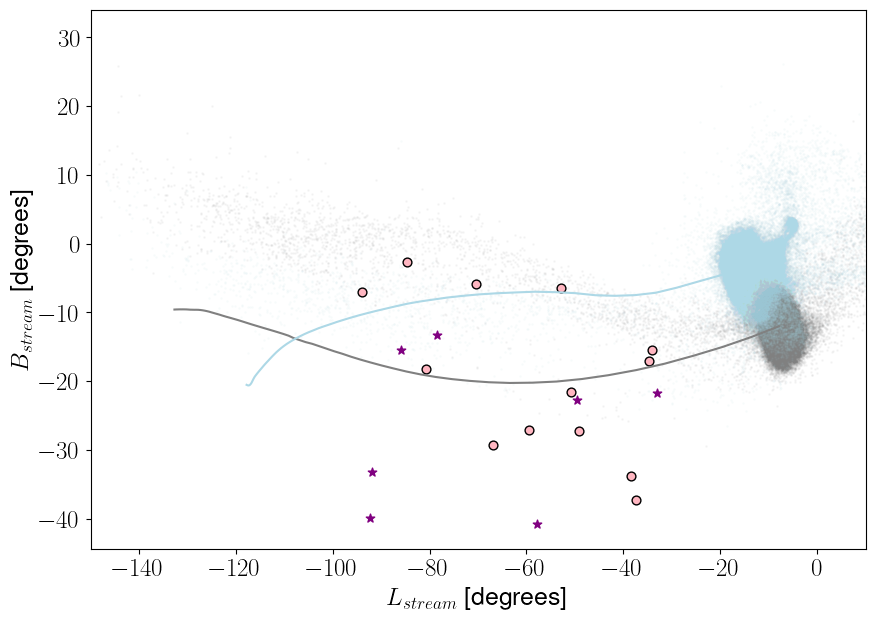

In [187]:
# show the L, B stream masking
fig, ax = plt.subplots(figsize=(10,7))
ax.scatter(smc1_sim['L_stream'], smc1_sim['B_stream'], s=1, color='gray', label='SMC Model 1', alpha=0.05)
ax.scatter(smc2_sim['L_stream'], smc2_sim['B_stream'], s=1, color='lightblue', label='SMC Model 2', alpha=0.05)

smc1_sim_lmc_masked = smc1_sim[(smc1_sim['L_stream'] >0) | (smc1_sim['L_stream'] < -20)]
smc2_sim_lmc_masked = smc2_sim[(smc2_sim['L_stream'] >0) | (smc2_sim['L_stream'] < -20)]
# now different color for the masked points
#ax.scatter(smc1_sim_lmc_masked['L_stream'], smc1_sim_lmc_masked['B_stream'], s=1, color='red', label='SMC Model 1 Masked', alpha=0.5)
#ax.scatter(smc2_sim_lmc_masked['L_stream'], smc2_sim_lmc_masked['B_stream'], s=1, color='blue', label='SMC Model 2 Masked', alpha=0.5)

#ax.plot(lmc_m1['L_stream'], lmc_m1['B_stream'], color='gray', label='LMC Model 1 COM Orbit')
#ax.plot(lmc_m2['L_stream'], lmc_m2['B_stream'], color='lightblue', label='LMC Model 2 COM Orbit')

ax.plot(smc_m1['L_stream'], smc_m1['B_stream'], color='gray', label='SMC Model 1 COM Orbit')
ax.plot(smc_m2['L_stream'], smc_m2['B_stream'], color='lightblue', label='SMC Model 2 COM Orbit')

# xshooter candidates and chandra stars
ax.scatter(xshooter_candidates['L_stream'], xshooter_candidates['B_stream'], s=dot_size_sel*2, c=color_xshooter, label='X-shooter Candidates', marker='*')
ax.scatter(chandra['L_stream'], chandra['B_stream'], s=dot_size_sel*2, c=chandra_color, label='Chandra MS Stars', edgecolors='k')

ax.set_xlabel(r'$L_{stream}$ [degrees]')
ax.set_ylabel(r'$B_{stream}$ [degrees]')
ax.set_xlim(-150, 10)
plt.savefig(os.path.join(plots_dir, 'smc_stream_masking_orbits.png'), dpi=600)
plt.show()

In [259]:
smc_m1

t,x,y,z,v_x,v_y,v_z,L_stream,B_stream,pm_l,pm_b,ra,dec,pm_ra,pm_dec,distance,radial_velocity,l_gal,b_gal
,,,,,,,,,mas / yr,mas / yr,,,mas / yr,mas / yr,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0.0,5.25502852031163,242.865714285714,-56.079,5.72741,-146.308,-69.7265,-132.6823794371003,-9.577037028843625,0.1382497206170585,0.011813610707516957,327.07257204995005,36.73744197797191,0.08099270423050717,-0.1126620100569535,249.6194842455607,-364.2699015678434,86.81363527468412,-12.979640079952244
0.0138571428571429,5.35102844238281,240.748571428571,-57.1768571428572,6.79897,-149.543,-69.3417,-132.31727983312325,-9.563755187237948,0.14167259253139858,0.011124165869679327,327.31586987858907,36.43474639308668,0.08173792575308005,-0.11624879369029084,247.8164005978248,-366.4048512297951,86.762231150245,-13.33640895612899
0.0277142857142857,5.47048568725586,238.63,-58.2135714285714,7.63577,-152.478,-68.6143,-131.95971213873491,-9.557694001480131,0.1447622702760039,0.010538077294513901,327.5445206327803,36.13409169351509,0.0824018229934591,-0.11948684252202252,246.00868655150896,-368.34525723352374,86.70432449056017,-13.684538421612196
0.0415714285714286,5.57367154530117,236.457142857143,-59.1901428571429,8.47655,-155.49,-67.6299,-131.60795987314438,-9.549998991825394,0.14773407743671674,0.009912743476209292,327.7692224077517,35.838587961951944,0.08296056752308763,-0.12264242477850049,244.14234956626223,-370.42359226065776,86.64858532203448,-14.027250766004874
0.0554285714285714,5.70664269583566,234.268571428571,-60.1064285714286,9.33724,-158.598,-66.5923,-131.26248262255635,-9.551261442087634,0.15073778029784862,0.009201227835485822,327.97855197058675,35.54334845928477,0.08346470185188956,-0.12585779494166482,242.2566362291306,-372.61458426090826,86.58436945324273,-14.36220551966149
0.0692857142857143,5.81207139151437,232.045714285714,-60.942,10.1105,-161.696,-65.4715,-130.92909583756364,-9.549160769849088,0.15369579548720105,0.008558972775936013,328.18227829398904,35.259595245668734,0.08400056312153116,-0.12899441445538817,240.324435098712,-374.8455444506251,86.52526463768008,-14.685961582559488
0.0831428571428572,5.94374316079276,229.75,-61.793,10.9472,-164.85,-64.4223,-130.58098478742855,-9.552507315712475,0.15693508072185514,0.007839910069247757,328.3872570214283,34.96003075960366,0.08458553530059477,-0.1324211877645754,238.33558851303667,-377.0534524875552,86.45737651620772,-15.022934066172972
0.097,6.0937431880406,227.411428571429,-62.6807142857143,11.886,-168.097,-63.5584,-130.21486010758812,-9.558516367646684,0.16057349812386212,0.007041810104041481,328.59819930172114,34.64319115165795,0.08526513074016175,-0.1362471756372896,236.3250395869386,-379.2269111737986,86.38282639413606,-15.37678965880816


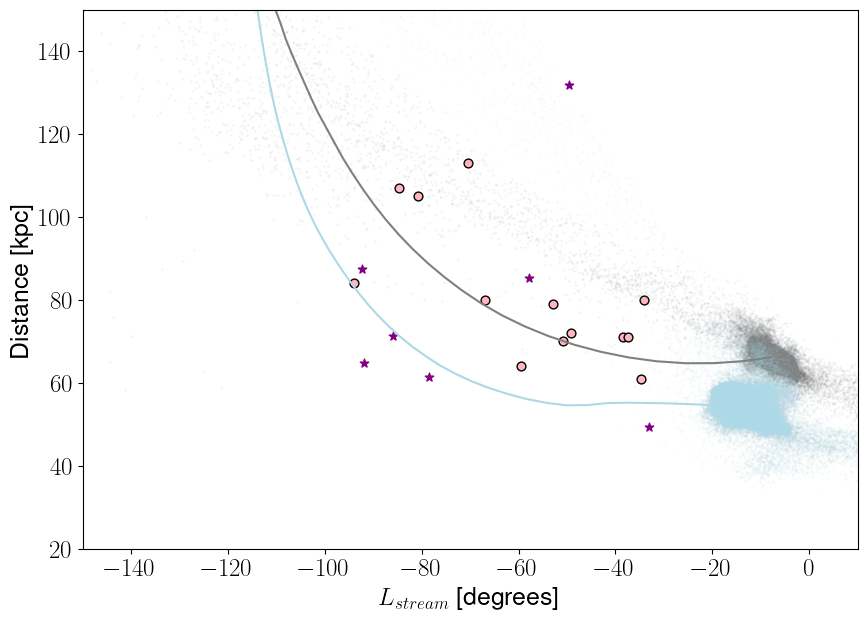

In [264]:
# plot orbit distance as a function of l
fig, ax = plt.subplots(figsize=(10,7))
# orbits
ax.plot(smc_m1['L_stream'], smc_m1['distance'], color='gray', label='SMC Model 1 COM Orbit')
ax.plot(smc_m2['L_stream'], smc_m2['distance'], color='lightblue', label='SMC Model 2 COM Orbit')
# xshooter candidates and chandra stars
ax.scatter(xshooter_candidates['L_stream'], xshooter_candidates['dist_pc_p50']/1000, s=dot_size_sel*2, c=color_xshooter, label='X-shooter Candidates', marker='*')
ax.scatter(chandra['L_stream'], chandra['distance'], s=dot_size_sel*2, c=chandra_color, label='Chandra MS Stars', edgecolors='k')
# b2012 models
ax.scatter(smc1_sim['L_stream'], smc1_sim['distance'], s=1, color='gray', label='SMC Model 1', alpha=0.05)
ax.scatter(smc2_sim['L_stream'], smc2_sim['distance'], s=1, color='lightblue', label='SMC Model 2', alpha=0.05)

ax.set_xlabel(r'$L_{stream}$ [degrees]')
ax.set_ylabel(r'Distance [kpc]')
ax.set_xlim(-150, 10)
ax.set_ylim(20, 150)
plt.savefig(os.path.join(plots_dir, 'smc_orbit_distance.png'), dpi=600)
plt.show()

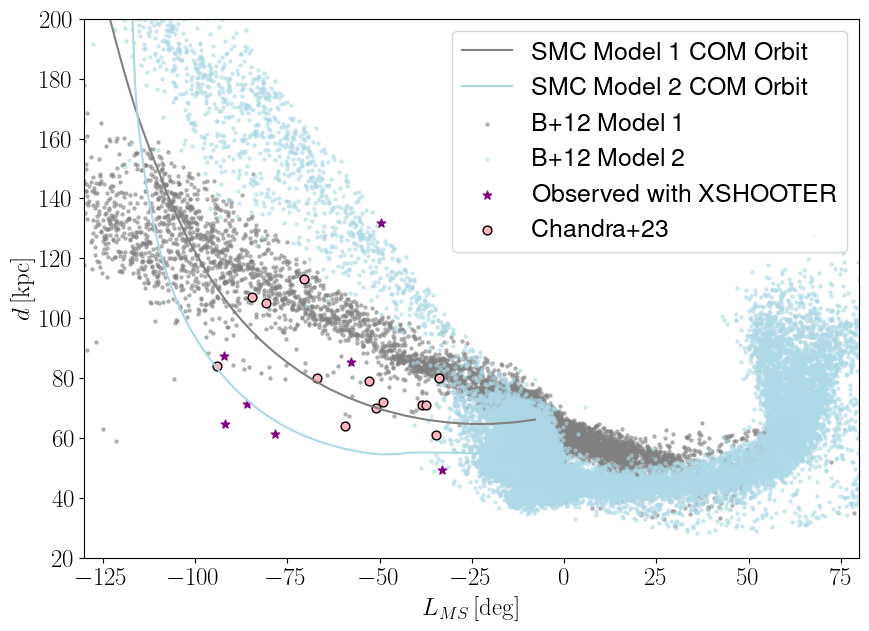

In [267]:
fig, ax = plt.subplots(figsize=(10,7))
# orbits
ax.plot(smc_m1['L_stream'], smc_m1['distance'], color='gray', label='SMC Model 1 COM Orbit')
ax.plot(smc_m2['L_stream'], smc_m2['distance'], color='lightblue', label='SMC Model 2 COM Orbit')
# b2012 models
ax.scatter(smc1_sim['L_stream'], smc1_sim['distance'], s=dot_size, color='gray',
            label='B+12 Model 1', alpha=0.5)
ax.scatter(smc2_sim['L_stream'], smc2_sim['distance'], s=dot_size, color='lightblue',
            label='B+12 Model 2', alpha=0.5)

ax.scatter(xshooter_candidates['L_stream'], xshooter_candidates['dist_pc_p50']/1000,
            s=dot_size_sel*2, c=color_xshooter, label='Observed with XSHOOTER', marker='*')

ax.scatter(chandra['L_stream'], chandra['distance'], s=dot_size_sel*2,
            c=chandra_color, label='Chandra+23', edgecolors='k')

ax.set_ylim(20, 200)
ax.set_xlim(-130, 80)
ax.set_ylabel(r'$d \,[\mathrm{kpc}]$')
ax.set_xlabel(r'$L_{MS} \,[\mathrm{deg}]$')
plt.legend(loc='upper right')
plt.savefig(os.path.join(plots_dir, 'xshooter_distance_comparison_new_orbits.png'), dpi=600)
plt.show()

/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_64946/3194726301.py:23: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(chandra['L_stream'], chandra_dist_diff_m2, s=dot_size_sel*2, c=chandra_color, label='Chandra vs SMC Model 2 Orbit', edgecolors='k', marker='x')


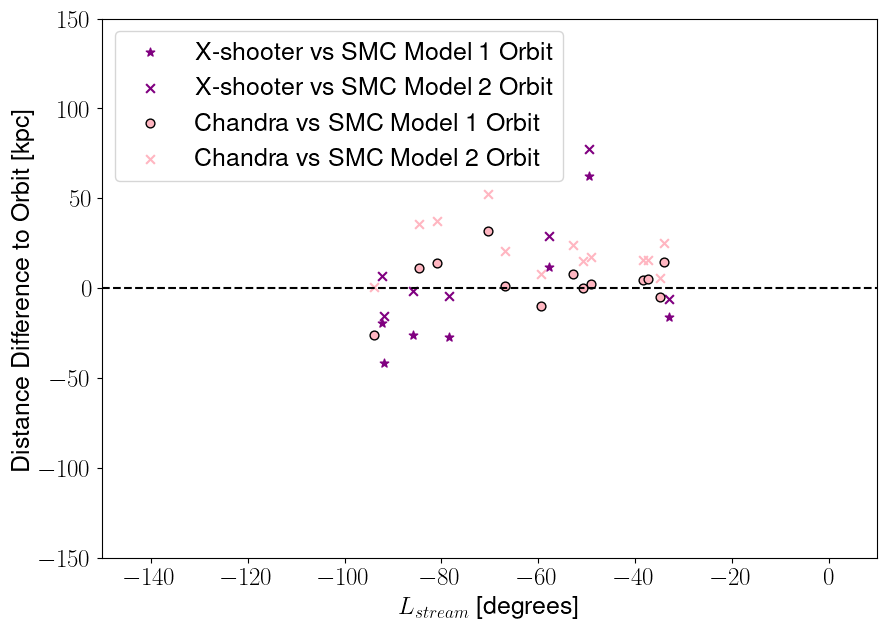

In [268]:
# interpolate the orbits in the same L value as the xshooter and chandra stars and compute the distance difference as a function of L stream

def interpolate_orbit_distance(orbit_table, L_values):
    interp_func = interp1d(orbit_table['L_stream'], orbit_table['distance'], bounds_error=False, fill_value=np.nan)
    return interp_func(L_values)
    
xshooter_orbit_dist_m1 = interpolate_orbit_distance(smc_m1, xshooter_candidates['L_stream'])
xshooter_orbit_dist_m2 = interpolate_orbit_distance(smc_m2, xshooter_candidates['L_stream'])
chandra_orbit_dist_m1 = interpolate_orbit_distance(smc_m1, chandra['L_stream'])
chandra_orbit_dist_m2 = interpolate_orbit_distance(smc_m2, chandra['L_stream'])

# now compute the distance difference between the candidates and the orbits
xshooter_dist_diff_m1 = xshooter_candidates['distance'] - xshooter_orbit_dist_m1
xshooter_dist_diff_m2 = xshooter_candidates['distance'] - xshooter_orbit_dist_m2
chandra_dist_diff_m1 = chandra['distance'] - chandra_orbit_dist_m1
chandra_dist_diff_m2 = chandra['distance'] - chandra_orbit_dist_m2

# plot the distance difference as a function of L stream
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(xshooter_candidates['L_stream'], xshooter_dist_diff_m1, s=dot_size_sel*2, c=color_xshooter, label='X-shooter vs SMC Model 1 Orbit', marker='*')     
ax.scatter(xshooter_candidates['L_stream'], xshooter_dist_diff_m2, s=dot_size_sel*2, c=color_xshooter, label='X-shooter vs SMC Model 2 Orbit', marker='x')
ax.scatter(chandra['L_stream'], chandra_dist_diff_m1, s=dot_size_sel*2, c=chandra_color, label='Chandra vs SMC Model 1 Orbit', edgecolors='k')
ax.scatter(chandra['L_stream'], chandra_dist_diff_m2, s=dot_size_sel*2, c=chandra_color, label='Chandra vs SMC Model 2 Orbit', edgecolors='k', marker='x')
ax.axhline(0, color='k', linestyle='--')
ax.set_xlabel(r'$L_{stream}$ [degrees]')
ax.set_ylabel('Distance Difference to Orbit [kpc]')
ax.set_xlim(-150, 10)
ax.set_ylim(-150, 150)
plt.legend()
plt.savefig(os.path.join(plots_dir, 'distance_difference_to_orbits.png'), dpi=600)
plt.show()

In [ ]:
# same but with old orbits


# Aitoff all sky plot including orbits

In [201]:
chandra

Gaia_eDR3_sourceid,RA,DEC,gmag,vgsr,feh,feh_error,alphafe,alphafe_error,Distance,Distance_error,fbound_LMC,DR3Name,RAdeg,DEdeg,errHalfMaj,errHalfMin,errPosAng,SolID,Source,RandomI,e_RAdeg,e_DEdeg,Plx,e_Plx,RPlx,PM,pmRA,e_pmRA,pmDE,e_pmDE,RADEcor,RAPlxcor,RApmRAcor,RApmDEcor,DEPlxcor,DEpmRAcor,DEpmDEcor,PlxpmRAcor,PlxpmDEcor,pmRApmDEcor,NAL,NAC,NgAL,NbAL,gofAL,chi2AL,epsi,sepsi,Solved,APF,nueff,pscol,e_pscol,RApscolCorr,DEpscolCorr,PlxpscolCorr,pmRApscolCorr,pmDEpscolCorr,MatchObsA,Nper,amax,MatchObs,IPDgofha,IPDgofhp,IPDfmp,IPDfow,RUWE,Dup,o_Gmag,FG,e_FG,RFG,Gmag,e_Gmag,o_BPmag,FBP,e_FBP,RFBP,BPmag,e_BPmag,o_RPmag,FRP,e_FRP,RFRP,RPmag,e_RPmag,E(BP/RP),NBPcont,NBPblend,NRPcont,NRPblend,Mode,BP-RP,BP-G,G-RP,RV,e_RV,n_RV,o_RV,o_RVd,RVNper,RVS/N,RVgof,RVchi2,RVTdur,RVamp,RVtempTeff,RVtemplogg,RVtemp[Fe/H],Vatmparam,vbroad,e_Vbroad,o_Vbroad,GRVSmag,e_GRVSmag,o_GRVSmag,RVSS/N,VarFlag,PQSO,PGal,PSS,Teff,b_Teff_x,B_Teff_xa,logg,b_logg_x,B_logg_xa,[Fe/H],b_[Fe/H]_x,B_[Fe/H]_xa,Dist,b_Dist_x,B_Dist_xa,A0,b_A0_x,B_A0_xa,AG,b_AG_x,B_AG_xa,E(BP-RP),b_E(BP-RP)_x,B_E(BP-RP)_xa,Lib,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,RADEcorJ2000,angDist,x,y,z,vx,vy,vz,Lx,Ly,Lz,L_stream,B_stream,pm_l,pm_b,distance,radial_velocity
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,kpc,kpc,kpc,km / s,km / s,km / s,kpc,kpc,kpc,,,mas / yr,mas / yr,,km / s
int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,str28,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,float64,int64,str5,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,int64,float64,float64,int64,int64,float64,int64,int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str13,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str7,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
6611869850296545024,333.05859,-33.8833,17.1,-110.3,-2.45,0.05,0.25,0.09,64,5,0.11,Gaia DR3 6611869850296545024,333.05859314712,-33.88330216643,0.0,0.0,73.0,1636148068921376768,6611869850296545024,207486085,0.0634,0.0514,-0.0978,0.0722,-1.3546,1.453,0.309,0.087,-1.419,0.063,0.1392,0.1007,-0.41,0.2104,-0.0009,0.2643,-0.5623,-0.2432,-0.0011,0.0152,570,0,566,4,2.0591,659.5,0.179,1.3618,31,false,1.458,--,--,--,--,--,--,--,65,20,0.124725,66,0.01832,158.4,0,0,1.061,0,543,2614.96893,1.60592,1628.33,17.1437,0.002835,61,1141.05,8.41304,135.628,17.695284,0.008478,59,2127.53,7.77321,273.701,16.428204,0.005479,1.25,0,1,0,1,0,1.26708,0.551584,0.715496,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,NOT_AVAILABLE,0.0,0.0,0.999996,5013.2,4801.0,5384.3,4.2988,4.2537,4.3315,-1.3506,-1.7692,-0.7888,1876.5206,1654.3492,2457.332,0.5801,0.375,0.8624,0.4592,0.2945,0.6898,0.2493,0.1598,0.3734,PHOENIX,333.05859149262,-33.88329585804,1.412833,1.035745,-0.0072,0.012218,27.43337440886085,7.4592234601138365,-52.668641351869425,-34.15587738508539,-204.50817739179362,46.282105664371365,-10425.939280217723,529.2693229323309,-5355.573078171205,-59.391378420977844,-27.169267906822192,1.43691428616746,0.21052157658506782,64.0,-110.3
6619464348908375808,329.91349,-27.49912,17.6,-74.7,-2.25,0.04,0.4,0.06,80,6,0.01,Gaia DR3 6619464348908375808,329.91349341

In [204]:
from astropy.coordinates import SkyCoord, Galactocentric, Galactic

def add_galactic_coords(orbit_table):
    coords = SkyCoord(x = orbit_table['x']*u.kpc, y = orbit_table['y']*u.kpc, z = orbit_table['z']*u.kpc,
                      v_x = orbit_table['v_x']*u.km/u.s, v_y = orbit_table['v_y']*u.km/u.s, v_z = orbit_table['v_z']*u.km/u.s,
                      frame=Galactocentric())
    galactic_coords = coords.transform_to(Galactic())
    orbit_table['l_gal'] = galactic_coords.l.degree
    orbit_table['b_gal'] = galactic_coords.b.degree
    return orbit_table

smc_m1 = add_galactic_coords(smc_m1)
smc_m2 = add_galactic_coords(smc_m2)
lmc_m1 = add_galactic_coords(lmc_m1)
lmc_m2 = add_galactic_coords(lmc_m2)

smc1_sim = add_galactic_coords(smc1_sim)
smc2_sim = add_galactic_coords(smc2_sim)

smc2_sim_lmc_masked = add_galactic_coords(smc2_sim_lmc_masked)
smc1_sim_lmc_masked = add_galactic_coords(smc1_sim_lmc_masked)

# same for the xshooter candidates and chandra stars
coords_candidates = SkyCoord(ra=xshooter_candidates['ra']*u.degree, dec=xshooter_candidates['dec']*u.degree,
                            pm_ra_cosdec=xshooter_candidates['pmra']*u.mas/u.yr, pm_dec=xshooter_candidates['pmdec']*u.mas/u.yr,
                            distance=xshooter_candidates['distance']*u.kpc, radial_velocity=xshooter_candidates['hel_vel']*u.km/u.s, frame=ICRS())
galactic_candidates = coords_candidates.transform_to(Galactic())
xshooter_candidates['l_gal'] = galactic_candidates.l.degree
xshooter_candidates['b_gal'] = galactic_candidates.b.degree

# for chandra stars
coords_chandra = SkyCoord(x = chandra['x'], y = chandra['y'], z = chandra['z'],
                          v_x = chandra['vx'], v_y = chandra['vy'], v_z = chandra['vz'], frame=Galactocentric())
galactic_chandra = coords_chandra.transform_to(Galactic())
chandra['l_gal'] = galactic_chandra.l.degree
chandra['b_gal'] = galactic_chandra.b.degree

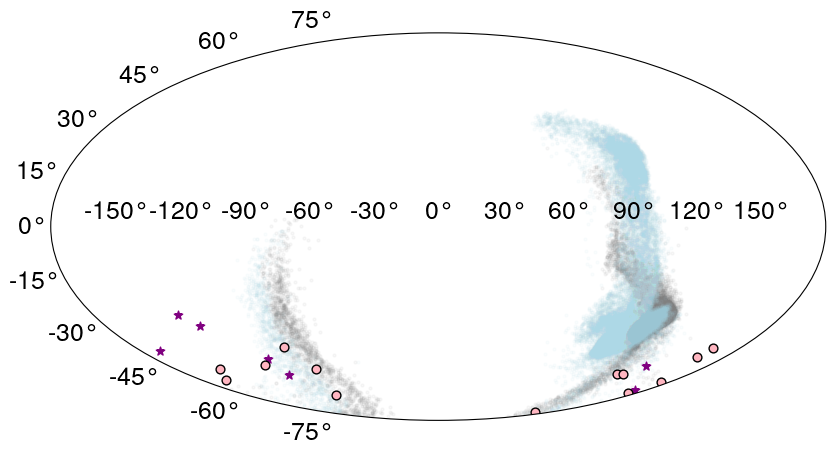

In [208]:
# aitoff projection of the sims and the candidates, this should use ra, dec coordinates
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='aitoff')
ax.scatter(np.radians(smc1_sim['l_gal'] - 180), np.radians(smc1_sim['b_gal']),
            s=dot_size, color='gray', label='SMC Model 1', alpha=0.05)
ax.scatter(np.radians(smc2_sim['l_gal'] - 180), np.radians(smc2_sim['b_gal']),
            s=dot_size, color='lightblue', label='SMC Model 2', alpha=0.05)
ax.scatter(np.radians(xshooter_candidates['l_gal'] - 180), np.radians(xshooter_candidates['b_gal']),
            s=dot_size_sel*2, c=color_xshooter, label='X-shooter Candidates', marker='*')
ax.scatter(np.radians(chandra['l_gal'] - 180), np.radians(chandra['b_gal']), s=dot_size_sel*2, c=chandra_color, label='Chandra MS Stars', edgecolors='k')

plt.show()


# FEH

In [210]:
# smc
smc = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/Muñoz_2023/smc_density.csv')
lmc = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/Muñoz_2023/lmc_density.csv')

In [220]:
chandra

Gaia_eDR3_sourceid,RA,DEC,gmag,vgsr,feh,feh_error,alphafe,alphafe_error,Distance,Distance_error,fbound_LMC,DR3Name,RAdeg,DEdeg,errHalfMaj,errHalfMin,errPosAng,SolID,Source,RandomI,e_RAdeg,e_DEdeg,Plx,e_Plx,RPlx,PM,pmRA,e_pmRA,pmDE,e_pmDE,RADEcor,RAPlxcor,RApmRAcor,RApmDEcor,DEPlxcor,DEpmRAcor,DEpmDEcor,PlxpmRAcor,PlxpmDEcor,pmRApmDEcor,NAL,NAC,NgAL,NbAL,gofAL,chi2AL,epsi,sepsi,Solved,APF,nueff,pscol,e_pscol,RApscolCorr,DEpscolCorr,PlxpscolCorr,pmRApscolCorr,pmDEpscolCorr,MatchObsA,Nper,amax,MatchObs,IPDgofha,IPDgofhp,IPDfmp,IPDfow,RUWE,Dup,o_Gmag,FG,e_FG,RFG,Gmag,e_Gmag,o_BPmag,FBP,e_FBP,RFBP,BPmag,e_BPmag,o_RPmag,FRP,e_FRP,RFRP,RPmag,e_RPmag,E(BP/RP),NBPcont,NBPblend,NRPcont,NRPblend,Mode,BP-RP,BP-G,G-RP,RV,e_RV,n_RV,o_RV,o_RVd,RVNper,RVS/N,RVgof,RVchi2,RVTdur,RVamp,RVtempTeff,RVtemplogg,RVtemp[Fe/H],Vatmparam,vbroad,e_Vbroad,o_Vbroad,GRVSmag,e_GRVSmag,o_GRVSmag,RVSS/N,VarFlag,PQSO,PGal,PSS,Teff,b_Teff_x,B_Teff_xa,logg,b_logg_x,B_logg_xa,[Fe/H],b_[Fe/H]_x,B_[Fe/H]_xa,Dist,b_Dist_x,B_Dist_xa,A0,b_A0_x,B_A0_xa,AG,b_AG_x,B_AG_xa,E(BP-RP),b_E(BP-RP)_x,B_E(BP-RP)_xa,Lib,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,RADEcorJ2000,angDist,x,y,z,vx,vy,vz,Lx,Ly,Lz,L_stream,B_stream,pm_l,pm_b,distance,radial_velocity,l_gal,b_gal
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,kpc,kpc,kpc,km / s,km / s,km / s,kpc,kpc,kpc,,,mas / yr,mas / yr,,km / s,,
int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,str28,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,float64,int64,str5,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,int64,float64,float64,int64,int64,float64,int64,int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str13,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str7,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
6611869850296545024,333.05859,-33.8833,17.1,-110.3,-2.45,0.05,0.25,0.09,64,5,0.11,Gaia DR3 6611869850296545024,333.05859314712,-33.88330216643,0.0,0.0,73.0,1636148068921376768,6611869850296545024,207486085,0.0634,0.0514,-0.0978,0.0722,-1.3546,1.453,0.309,0.087,-1.419,0.063,0.1392,0.1007,-0.41,0.2104,-0.0009,0.2643,-0.5623,-0.2432,-0.0011,0.0152,570,0,566,4,2.0591,659.5,0.179,1.3618,31,false,1.458,--,--,--,--,--,--,--,65,20,0.124725,66,0.01832,158.4,0,0,1.061,0,543,2614.96893,1.60592,1628.33,17.1437,0.002835,61,1141.05,8.41304,135.628,17.695284,0.008478,59,2127.53,7.77321,273.701,16.428204,0.005479,1.25,0,1,0,1,0,1.26708,0.551584,0.715496,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,NOT_AVAILABLE,0.0,0.0,0.999996,5013.2,4801.0,5384.3,4.2988,4.2537,4.3315,-1.3506,-1.7692,-0.7888,1876.5206,1654.3492,2457.332,0.5801,0.375,0.8624,0.4592,0.2945,0.6898,0.2493,0.1598,0.3734,PHOENIX,333.05859149262,-33.88329585804,1.412833,1.035745,-0.0072,0.012218,27.43337440886085,7.4592234601138365,-52.668641351869425,-34.15587738508539,-204.50817739179362,46.282105664371365,-10425.939280217723,529.2693229323309,-5355.573078171205,-59.391378420977844,-27.169267906822192,1.43691428616746,0.21052157658506782,64.0,-110.3,11.804818348759438,-55.27022098282793
6619464348908375808,329.91349,-27.49912,17.6,-74.7,-2.

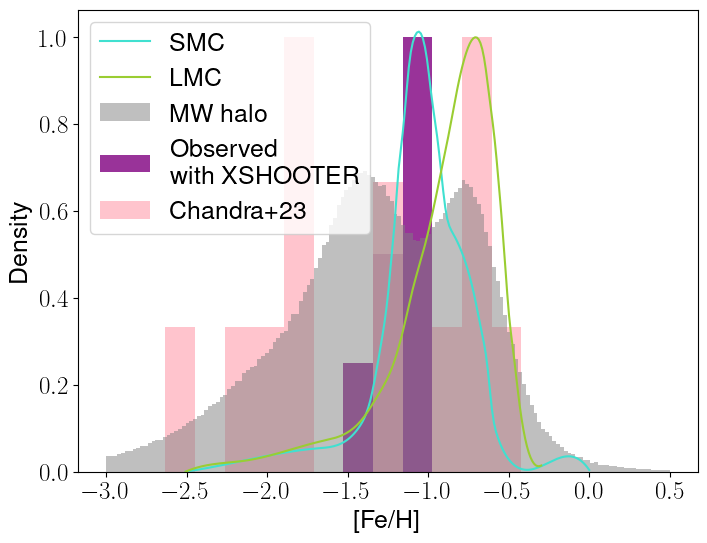

In [231]:
from scipy.interpolate import interp1d
import numpy as np

# plot smc and lmc density
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# smooth the smc using a linear KDE
# plot the outline of the lmc and smc, normalized to [0, 1]
smc_y_norm = -(-smc['y'] - min(-smc['y'])) / (max(-smc['y']) - min(-smc['y'])) + 1
lmc_y_norm = -(-lmc['y'] - min(-lmc['y'])) / (max(-lmc['y']) - min(-lmc['y'])) + 1
# Interpolate SMC and LMC density curves for smoothing
smc_interp = interp1d(smc['x'], smc_y_norm, kind='cubic')
lmc_interp = interp1d(lmc['x'], lmc_y_norm, kind='cubic')

x_smc = np.linspace(np.min(smc['x']), np.max(smc['x']), 200)
x_lmc = np.linspace(np.min(lmc['x']), np.max(lmc['x']), 200)

ax.plot(x_smc, smc_interp(x_smc), label='SMC', color='turquoise')
ax.plot(x_lmc, lmc_interp(x_lmc), label='LMC', color='yellowgreen')
# ax.hist(xshooter_candidates['feh'], bins=10, density=True,
#          alpha=0.8, color='purple', label='Observed \n with XSHOOTER')
bins_stars = np.linspace(-3, 0.5, 20)
vals = np.array(xshooter_candidates['feh'])
counts, edges = np.histogram(vals, bins=bins_stars)
counts = counts / counts.max()  # peak -> 1
centers = 0.5*(edges[1:] + edges[:-1])
widths  = edges[1:] - edges[:-1]

ax.bar(centers, counts, width=widths, alpha=0.8, color=color_xshooter,
       label='Observed \n with XSHOOTER', align='center')


# ax.hist(chandra['feh'], bins=10, alpha=0.8, color=chandra_color, 
#         label='Chandra+23', edgecolor='k', density=True)
vals = np.array(chandra['feh'])
counts, edges = np.histogram(vals, bins=bins_stars)
counts = counts / counts.max()  # peak -> 1
centers = 0.5*(edges[1:] + edges[:-1])
widths  = edges[1:] - edges[:-1]

ax.bar(centers, counts, width=widths, alpha=0.8, color=chandra_color,
       label='Chandra+23', align='center')



ax.hist(desi_halo_stars['FEH'], bins=np.linspace(-3, 0.5, 150),
         alpha=0.5, color='gray', label='MW halo', density=True)

ax.set_xlabel(r'[Fe/H]')
ax.set_ylabel('Density')
ax.legend()
plt.show()

In [233]:
xshooter_candidates

OBJECT,arm,Teff,logg,feh,alpha,vsini,vel,hel_vel,vel_err,vel_skewness,vel_kurtosis,teff_err,logg_err,feh_err,alpha_err,minimize_success,bad_hessian,chisq,logl,npix,chisq_red,filename,source_id,a_image_g,a_image_i,a_image_r,a_image_z,b_image_g,b_image_i,b_image_r,b_image_z,ccdnum_g,ccdnum_i,ccdnum_r,ccdnum_z,class_star_g,class_star_i,class_star_r,class_star_z,dec,ebv,expnum_g,expnum_i,expnum_r,expnum_z,exptime_g,exptime_i,exptime_r,exptime_z,extended_class_g,extended_class_i,extended_class_r,extended_class_z,extinction_g,extinction_i,extinction_r,extinction_z,flags_g,flags_i,flags_r,flags_z,hpx2048,htm9,mag_auto_g,mag_auto_i,mag_auto_r,mag_auto_z,mag_psf_g,mag_psf_i,mag_psf_r,mag_psf_z,magerr_auto_g,magerr_auto_i,magerr_auto_r,magerr_auto_z,magerr_psf_g,magerr_psf_i,magerr_psf_r,magerr_psf_z,nepochs_g,nepochs_i,nepochs_r,nepochs_z,nest4096,quick_object_id,ra,random_id,ring256,spread_model_g,spread_model_i,spread_model_r,spread_model_z,spreaderr_model_g,spreaderr_model_i,spreaderr_model_r,spreaderr_model_z,t_eff_g,t_eff_i,t_eff_r,t_eff_z,theta_image_g,theta_image_i,theta_image_r,theta_image_z,wavg_flags_g,wavg_flags_i,wavg_flags_r,wavg_flags_z,wavg_mag_auto_g,wavg_mag_auto_i,wavg_mag_auto_r,wavg_mag_auto_z,DECam_g,DECam_i,DECam_r,DECam_z,wavg_magerr_auto_g,wavg_magerr_auto_i,wavg_magerr_auto_r,wavg_magerr_auto_z,DECam_g_ERR,DECam_i_ERR,DECam_r_ERR,DECam_z_ERR,wavg_magrms_auto_g,wavg_magrms_auto_i,wavg_magrms_auto_r,wavg_magrms_auto_z,wavg_magrms_psf_g,wavg_magrms_psf_i,wavg_magrms_psf_r,wavg_magrms_psf_z,wavg_spread_model_g,wavg_spread_model_i,wavg_spread_model_r,wavg_spread_model_z,wavg_spreaderr_model_g,wavg_spreaderr_model_i,wavg_spreaderr_model_r,wavg_spreaderr_model_z,wavg_spreadrms_model_g,wavg_spreadrms_model_i,wavg_spreadrms_model_r,wavg_spreadrms_model_z,mjd_obs,elon,elat,glon,glat,on_sky_distance_arcsec,SOURCEID,CUEVENTID,FRAMESETID,RA2000,DEC2000,L,B,LAMBDA,ETA,PRIORSEC,YMJPNT,YMJPNTERR,JMHPNT,JMHPNTERR,HMKSPNT,HMKSPNTERR,JMKSPNT,JMKSPNTERR,YMJEXT,YMJEXTERR,JMHEXT,JMHEXTERR,HMKSEXT,HMKSEXTERR,JMKSEXT,JMKSEXTERR,MERGEDCLASSSTAT,MERGEDCLASS,PSTAR,PGALAXY,PNOISE,PSATURATED,EBV,AY,AJ,AH,AKS,YMJD,YPETROMAG,YPETROMAGERR,YPSFMAG,YPSFMAGERR,YSERMAG2D,YSERMAG2DERR,YAPERMAG3,YAPERMAG3ERR,YAPERMAG4,YAPERMAG4ERR,YAPERMAG6,YAPERMAG6ERR,YAPERMAGNOAPERCORR3,YAPERMAGNOAPERCORR4,YAPERMAGNOAPERCORR6,YHLCORSMJRADAS,YGAUSIG,YELL,YPA,YERRBITS,YAVERAGECONF,YCLASS,YCLASSSTAT,YPPERRBITS,YSEQNUM,YXI,YETA,JMJD,JPETROMAG,JPETROMAGERR,JPSFMAG,JPSFMAGERR,JSERMAG2D,JSERMAG2DERR,VISTA_J,2MASS_J_ERR,JAPERMAG4,JAPERMAG4ERR,JAPERMAG6,JAPERMAG6ERR,JAPERMAGNOAPERCORR3,JAPERMAGNOAPERCORR4,JAPERMAGNOAPERCORR6,JHLCORSMJRADAS,JGAUSIG,JELL,JPA,JERRBITS,JAVERAGECONF,JCLASS,JCLASSSTAT,JPPERRBITS,JSEQNUM,JXI,JETA,HMJD,HPETROMAG,HPETROMAGERR,HPSFMAG,HPSFMAGERR,HSERMAG2D,HSERMAG2DERR,VISTA_H,2MASS_H_ERR,HAPERMAG4,HAPERMAG4ERR,HAPERMAG6,HAPERMAG6ERR,HAPERMAGNOAPERCORR3,HAPERMAGNOAPERCORR4,HAPERMAGNOAPERCORR6,HHLCORSMJRADAS,HGAUSIG,HELL,HPA,HERRBITS,HAVERAGECONF,HCLASS,HCLASSSTAT,HPPERRBITS,HSEQNUM,HXI,HETA,KSMJD,KSPETROMAG,KSPETROMAGERR,KSPSFMAG,KSPSFMAGERR,KSSERMAG2D,KSSERMAG2DERR,VISTA_Ks,2MASS_Ks_ERR,KSAPERMAG4,KSAPERMAG4ERR,KSAPERMAG6,KSAPERMAG6ERR,KSAPERMAGNOAPERCORR3,KSAPERMAGNOAPERCORR4,KSAPERMAGNOAPERCORR6,KSHLCORSMJRADAS,KSGAUSIG,KSELL,KSPA,KSERRBITS,KSAVERAGECONF,KSCLASS,KSCLASSSTAT,KSPPERRBITS,KSSEQNUM,KSXI,KSETA,PRIMARY_SOURCE,g_i,i_Ks,gmag,dist_1,g_ABS_1,dist_2,g_ABS_2,dist_3,g_ABS_3,dist_4,g_ABS_4,L_stream,B_stream,ra_epoch2000,dec_epoch2000,errHalfMaj,errHalfMin,errPosAng,ra_x,ra_error,dec_x,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,astrometric_n_good_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,pseudocolour,pseudocolour_error,visibility_periods_used,ruwe,duplicated_source,phot_g_mean_flux,phot_g_mean_flux_error,Gaia_G_EDR3,phot_bp_mean_flux,phot_bp_mean_flux_error,Gaia_BP_EDR3,phot_rp_mean_flux,Gaia_RP_EDR3,phot_bp_rp_ex

In [234]:
chandra

Gaia_eDR3_sourceid,RA,DEC,gmag,vgsr,feh,feh_error,alphafe,alphafe_error,Distance,Distance_error,fbound_LMC,DR3Name,RAdeg,DEdeg,errHalfMaj,errHalfMin,errPosAng,SolID,Source,RandomI,e_RAdeg,e_DEdeg,Plx,e_Plx,RPlx,PM,pmRA,e_pmRA,pmDE,e_pmDE,RADEcor,RAPlxcor,RApmRAcor,RApmDEcor,DEPlxcor,DEpmRAcor,DEpmDEcor,PlxpmRAcor,PlxpmDEcor,pmRApmDEcor,NAL,NAC,NgAL,NbAL,gofAL,chi2AL,epsi,sepsi,Solved,APF,nueff,pscol,e_pscol,RApscolCorr,DEpscolCorr,PlxpscolCorr,pmRApscolCorr,pmDEpscolCorr,MatchObsA,Nper,amax,MatchObs,IPDgofha,IPDgofhp,IPDfmp,IPDfow,RUWE,Dup,o_Gmag,FG,e_FG,RFG,Gmag,e_Gmag,o_BPmag,FBP,e_FBP,RFBP,BPmag,e_BPmag,o_RPmag,FRP,e_FRP,RFRP,RPmag,e_RPmag,E(BP/RP),NBPcont,NBPblend,NRPcont,NRPblend,Mode,BP-RP,BP-G,G-RP,RV,e_RV,n_RV,o_RV,o_RVd,RVNper,RVS/N,RVgof,RVchi2,RVTdur,RVamp,RVtempTeff,RVtemplogg,RVtemp[Fe/H],Vatmparam,vbroad,e_Vbroad,o_Vbroad,GRVSmag,e_GRVSmag,o_GRVSmag,RVSS/N,VarFlag,PQSO,PGal,PSS,Teff,b_Teff_x,B_Teff_xa,logg,b_logg_x,B_logg_xa,[Fe/H],b_[Fe/H]_x,B_[Fe/H]_xa,Dist,b_Dist_x,B_Dist_xa,A0,b_A0_x,B_A0_xa,AG,b_AG_x,B_AG_xa,E(BP-RP),b_E(BP-RP)_x,B_E(BP-RP)_xa,Lib,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,RADEcorJ2000,angDist,x,y,z,vx,vy,vz,Lx,Ly,Lz,L_stream,B_stream,pm_l,pm_b,distance,radial_velocity,l_gal,b_gal
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,kpc,kpc,kpc,km / s,km / s,km / s,kpc,kpc,kpc,,,mas / yr,mas / yr,,km / s,,
int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,str28,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,float64,int64,str5,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,int64,float64,float64,int64,int64,float64,int64,int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str13,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str7,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
6611869850296545024,333.05859,-33.8833,17.1,-110.3,-2.45,0.05,0.25,0.09,64,5,0.11,Gaia DR3 6611869850296545024,333.05859314712,-33.88330216643,0.0,0.0,73.0,1636148068921376768,6611869850296545024,207486085,0.0634,0.0514,-0.0978,0.0722,-1.3546,1.453,0.309,0.087,-1.419,0.063,0.1392,0.1007,-0.41,0.2104,-0.0009,0.2643,-0.5623,-0.2432,-0.0011,0.0152,570,0,566,4,2.0591,659.5,0.179,1.3618,31,false,1.458,--,--,--,--,--,--,--,65,20,0.124725,66,0.01832,158.4,0,0,1.061,0,543,2614.96893,1.60592,1628.33,17.1437,0.002835,61,1141.05,8.41304,135.628,17.695284,0.008478,59,2127.53,7.77321,273.701,16.428204,0.005479,1.25,0,1,0,1,0,1.26708,0.551584,0.715496,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,NOT_AVAILABLE,0.0,0.0,0.999996,5013.2,4801.0,5384.3,4.2988,4.2537,4.3315,-1.3506,-1.7692,-0.7888,1876.5206,1654.3492,2457.332,0.5801,0.375,0.8624,0.4592,0.2945,0.6898,0.2493,0.1598,0.3734,PHOENIX,333.05859149262,-33.88329585804,1.412833,1.035745,-0.0072,0.012218,27.43337440886085,7.4592234601138365,-52.668641351869425,-34.15587738508539,-204.50817739179362,46.282105664371365,-10425.939280217723,529.2693229323309,-5355.573078171205,-59.391378420977844,-27.169267906822192,1.43691428616746,0.21052157658506782,64.0,-110.3,11.804818348759438,-55.27022098282793
6619464348908375808,329.91349,-27.49912,17.6,-74.7,-2.

In [236]:
desi_halo_stars

TARGETID_1,SOURCE_ID,ra,dec,pmra,pmra_error,pmdec,pmdec_error,VRAD_1,DIST,DISTERR,MG_NN,MG_GEO,parallax,parallax_error,PARALLAX_ZPC,EBV,A_G,RUWE,APS,NEUIA,P_COLOUR,ECL_LAT,BINARY_FLAG,VRAD_2,VRAD_ERR,VRAD_SKEW,VRAD_KURT,LOGG,TEFF,ALPHAFE,FEH,LOGG_ERR,TEFF_ERR,ALPHAFE_ERR,FEH_ERR,VSINI,CHISQ_TOT,CHISQ_C_TOT,CHISQ_B,CHISQ_C_B,CHISQ_R,CHISQ_C_R,CHISQ_Z,CHISQ_C_Z,RVS_WARN,REF_ID,REF_CAT,TARGET_RA,TARGET_DEC,TARGETID_2,SN_B,SN_R,SN_Z,SUCCESS,RR_Z,RR_SPECTYPE,HEALPIX,SURVEY,PROGRAM,PRIMARY,implied_parallax,implied_parallax_error,VGCR,VR,implied_distance,implied_distance_error,x,y,z,vx,vy,vz,lx,ly,lz
,,deg,deg,mas / yr,mas / yr,mas / yr,mas / yr,km / s,kpc,kpc,,,mas,mas,mas,,,,,,,,,km / s,km / s,,,,K,,,,K,,,km / s,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,kpc,kpc,kpc,km / s,km / s,km / s,kpc,kpc,kpc
int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,bytes2,float64,float64,int64,float32,float32,float32,bool,float64,bytes6,int64,bytes7,bytes6,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39628488923154106,303343026036947584,24.117762867223217,30.615017581955843,2.2997895971185516,0.1465865969657898,-2.7111488592461876,0.1146523654460907,-238.1485168248572,7.576852880262442,0.49392688717611416,3.3182644844055176,5.291925932638801,0.3275242305354504,0.13565650582313538,-0.025239000096917152,0.0583529993891716,0.16243836765767128,0.9834898114204407,31.0,1.602676510810852,--,19.108770171251493,1,-238.1485168248572,0.996139649005509,-0.001638774160048439,3.0010517572195354,4.306922006244297,6957.724440882306,0.35139822312888935,-1.4124343320514285,0.04385339589111399,20.71753613055993,0.03944965119865685,0.037360183252675074,0.014197116366368421,10267.592464747539,45170.90332224967,3245.4972024638214,32329.21922694928,3727.320717074319,4926.720000186742,3294.7745452093986,7914.964095113648,0,303343026036947584,G2,24.11776252618068,30.615017952329197,39628488923154106,49.181816,61.741634,55.475983,True,-0.0007877124096221329,STAR,2155,cmx,other,True,0.09253746037230674,0.0033685294632175046,-108.07101856983321,-238.3595391690816,10806.434453427742,393.3735884067324,-12.652784122215655,4.637811198590535,-3.8998071912190118,111.50241742546434,0.36425233127139905,63.97289936702245,298.1147429515926,374.5973560490317,-521.7359663193258
1152921504619433424,303373778003416448,23.659989967254145,30.696579550828726,0.25151413561403735,0.2702197730541229,-0.04681689116772876,0.15826255083084106,-207.22235335362188,6.432888774253349,4.262397851194701,4.682595729827881,-2.7130203024787605,0.005157874266081641,0.22186192870140076,-0.01735999993979931,0.04596899822354317,0.10965597936160876,0.9879470467567444,95.0,--,1.405266523361206,19.335719440640382,0,-207.22235335362188,0.19635350869568108,0.0002797623937627273,3.000107361853889,-0.2533105071769462,4558.044407681333,0.1477360928088569,-0.1868492255904235,0.023003428299369553,7.410006440317232,0.00633056846752256,0.01458473052352801,0.01,39061.03372778582,98050.17317369637,9658.284843624177,16626.490205036473,12950.760662637831,26855.59881337287,16451.988221523814,54568.084155287026,0,303373778003416448,F1,23.659988112828078,30.69657790790544,1152921504619433424,19.668367,41.961864,50.291267,True,-0.0006944429045459775,STAR,2155,cmx,other,True,0.003211266875727248,0.00486460592135138,10701.250234385825,10559.098140086408,311403.5795525504,471731.48655802285,-11.936314318397294,3.969033471830945,-3.3078084752037493,130.10613446069115,112.38254828358242,115.10102315375507,828.5797592166709,943.5158164872722,-1857.8290227803209
1152921504619433024,303386765984823808,23.627027345461176,30.772729107452218,0.39708719882761573,0.306

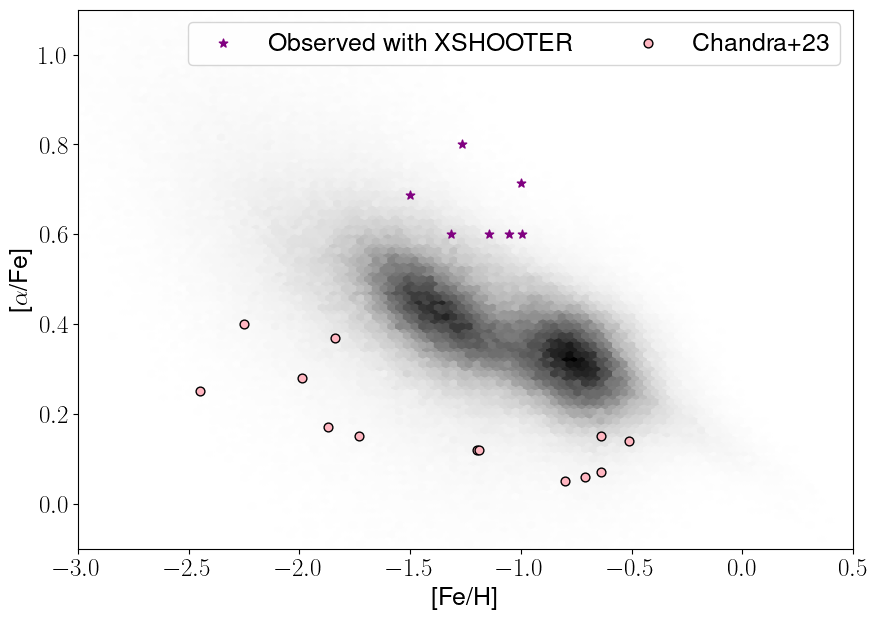

In [251]:
# alpha vs feh
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# add the desi halo stars
ax.hexbin(desi_halo_stars['FEH'], desi_halo_stars['ALPHAFE'],
           gridsize=100, cmap='Greys', mincnt=1, #label='MW halo',
           #norm=LogNorm(),
           extent=(-3, 0.5, -0.1, 1.1))

ax.scatter(xshooter_candidates['feh'], xshooter_candidates['alpha'], s=dot_size_sel*2, c=color_xshooter, label='Observed with XSHOOTER', marker='*')
ax.scatter(chandra['feh'], chandra['alphafe'], s=dot_size_sel*2, c=chandra_color, label='Chandra+23', edgecolors='k')

ax.set_xlabel(r'[Fe/H]')
ax.set_ylabel(r'[$\alpha$/Fe]')
ax.set_xlim(-3, 0.5)
ax.set_ylim(-0.1, 1.1)
ax.legend(ncols = 2)
plt.show()

In [252]:
# save candidates and chandra data to csv
xshooter_candidates.write(os.path.join(plots_dir, 'xshooter_candidates.csv'), format='csv', overwrite=True)
chandra.write(os.path.join(plots_dir, 'chandra_ms_stars.csv'), format='csv', overwrite=True)

In [254]:
xshooter_candidates

OBJECT,arm,Teff,logg,feh,alpha,vsini,vel,hel_vel,vel_err,vel_skewness,vel_kurtosis,teff_err,logg_err,feh_err,alpha_err,minimize_success,bad_hessian,chisq,logl,npix,chisq_red,filename,source_id,a_image_g,a_image_i,a_image_r,a_image_z,b_image_g,b_image_i,b_image_r,b_image_z,ccdnum_g,ccdnum_i,ccdnum_r,ccdnum_z,class_star_g,class_star_i,class_star_r,class_star_z,dec,ebv,expnum_g,expnum_i,expnum_r,expnum_z,exptime_g,exptime_i,exptime_r,exptime_z,extended_class_g,extended_class_i,extended_class_r,extended_class_z,extinction_g,extinction_i,extinction_r,extinction_z,flags_g,flags_i,flags_r,flags_z,hpx2048,htm9,mag_auto_g,mag_auto_i,mag_auto_r,mag_auto_z,mag_psf_g,mag_psf_i,mag_psf_r,mag_psf_z,magerr_auto_g,magerr_auto_i,magerr_auto_r,magerr_auto_z,magerr_psf_g,magerr_psf_i,magerr_psf_r,magerr_psf_z,nepochs_g,nepochs_i,nepochs_r,nepochs_z,nest4096,quick_object_id,ra,random_id,ring256,spread_model_g,spread_model_i,spread_model_r,spread_model_z,spreaderr_model_g,spreaderr_model_i,spreaderr_model_r,spreaderr_model_z,t_eff_g,t_eff_i,t_eff_r,t_eff_z,theta_image_g,theta_image_i,theta_image_r,theta_image_z,wavg_flags_g,wavg_flags_i,wavg_flags_r,wavg_flags_z,wavg_mag_auto_g,wavg_mag_auto_i,wavg_mag_auto_r,wavg_mag_auto_z,DECam_g,DECam_i,DECam_r,DECam_z,wavg_magerr_auto_g,wavg_magerr_auto_i,wavg_magerr_auto_r,wavg_magerr_auto_z,DECam_g_ERR,DECam_i_ERR,DECam_r_ERR,DECam_z_ERR,wavg_magrms_auto_g,wavg_magrms_auto_i,wavg_magrms_auto_r,wavg_magrms_auto_z,wavg_magrms_psf_g,wavg_magrms_psf_i,wavg_magrms_psf_r,wavg_magrms_psf_z,wavg_spread_model_g,wavg_spread_model_i,wavg_spread_model_r,wavg_spread_model_z,wavg_spreaderr_model_g,wavg_spreaderr_model_i,wavg_spreaderr_model_r,wavg_spreaderr_model_z,wavg_spreadrms_model_g,wavg_spreadrms_model_i,wavg_spreadrms_model_r,wavg_spreadrms_model_z,mjd_obs,elon,elat,glon,glat,on_sky_distance_arcsec,SOURCEID,CUEVENTID,FRAMESETID,RA2000,DEC2000,L,B,LAMBDA,ETA,PRIORSEC,YMJPNT,YMJPNTERR,JMHPNT,JMHPNTERR,HMKSPNT,HMKSPNTERR,JMKSPNT,JMKSPNTERR,YMJEXT,YMJEXTERR,JMHEXT,JMHEXTERR,HMKSEXT,HMKSEXTERR,JMKSEXT,JMKSEXTERR,MERGEDCLASSSTAT,MERGEDCLASS,PSTAR,PGALAXY,PNOISE,PSATURATED,EBV,AY,AJ,AH,AKS,YMJD,YPETROMAG,YPETROMAGERR,YPSFMAG,YPSFMAGERR,YSERMAG2D,YSERMAG2DERR,YAPERMAG3,YAPERMAG3ERR,YAPERMAG4,YAPERMAG4ERR,YAPERMAG6,YAPERMAG6ERR,YAPERMAGNOAPERCORR3,YAPERMAGNOAPERCORR4,YAPERMAGNOAPERCORR6,YHLCORSMJRADAS,YGAUSIG,YELL,YPA,YERRBITS,YAVERAGECONF,YCLASS,YCLASSSTAT,YPPERRBITS,YSEQNUM,YXI,YETA,JMJD,JPETROMAG,JPETROMAGERR,JPSFMAG,JPSFMAGERR,JSERMAG2D,JSERMAG2DERR,VISTA_J,2MASS_J_ERR,JAPERMAG4,JAPERMAG4ERR,JAPERMAG6,JAPERMAG6ERR,JAPERMAGNOAPERCORR3,JAPERMAGNOAPERCORR4,JAPERMAGNOAPERCORR6,JHLCORSMJRADAS,JGAUSIG,JELL,JPA,JERRBITS,JAVERAGECONF,JCLASS,JCLASSSTAT,JPPERRBITS,JSEQNUM,JXI,JETA,HMJD,HPETROMAG,HPETROMAGERR,HPSFMAG,HPSFMAGERR,HSERMAG2D,HSERMAG2DERR,VISTA_H,2MASS_H_ERR,HAPERMAG4,HAPERMAG4ERR,HAPERMAG6,HAPERMAG6ERR,HAPERMAGNOAPERCORR3,HAPERMAGNOAPERCORR4,HAPERMAGNOAPERCORR6,HHLCORSMJRADAS,HGAUSIG,HELL,HPA,HERRBITS,HAVERAGECONF,HCLASS,HCLASSSTAT,HPPERRBITS,HSEQNUM,HXI,HETA,KSMJD,KSPETROMAG,KSPETROMAGERR,KSPSFMAG,KSPSFMAGERR,KSSERMAG2D,KSSERMAG2DERR,VISTA_Ks,2MASS_Ks_ERR,KSAPERMAG4,KSAPERMAG4ERR,KSAPERMAG6,KSAPERMAG6ERR,KSAPERMAGNOAPERCORR3,KSAPERMAGNOAPERCORR4,KSAPERMAGNOAPERCORR6,KSHLCORSMJRADAS,KSGAUSIG,KSELL,KSPA,KSERRBITS,KSAVERAGECONF,KSCLASS,KSCLASSSTAT,KSPPERRBITS,KSSEQNUM,KSXI,KSETA,PRIMARY_SOURCE,g_i,i_Ks,gmag,dist_1,g_ABS_1,dist_2,g_ABS_2,dist_3,g_ABS_3,dist_4,g_ABS_4,L_stream,B_stream,ra_epoch2000,dec_epoch2000,errHalfMaj,errHalfMin,errPosAng,ra_x,ra_error,dec_x,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,astrometric_n_good_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,pseudocolour,pseudocolour_error,visibility_periods_used,ruwe,duplicated_source,phot_g_mean_flux,phot_g_mean_flux_error,Gaia_G_EDR3,phot_bp_mean_flux,phot_bp_mean_flux_error,Gaia_BP_EDR3,phot_rp_mean_flux,Gaia_RP_EDR3,phot_bp_rp_ex

In [258]:
xshooter_merged.write('/Users/mncavieres/Documents/2024-1/Delve/Data/final_tables/all_xshooter.csv', format='csv', overwrite=True)
xshooter_candidates.write('/Users/mncavieres/Documents/2024-1/Delve/Data/final_tables/xshooter_candidates.csv', format='csv', overwrite=True)
chandra.write('/Users/mncavieres/Documents/2024-1/Delve/Data/final_tables/chandra_ms_stars.csv', format='csv', overwrite=True)

# Coloured by Feh

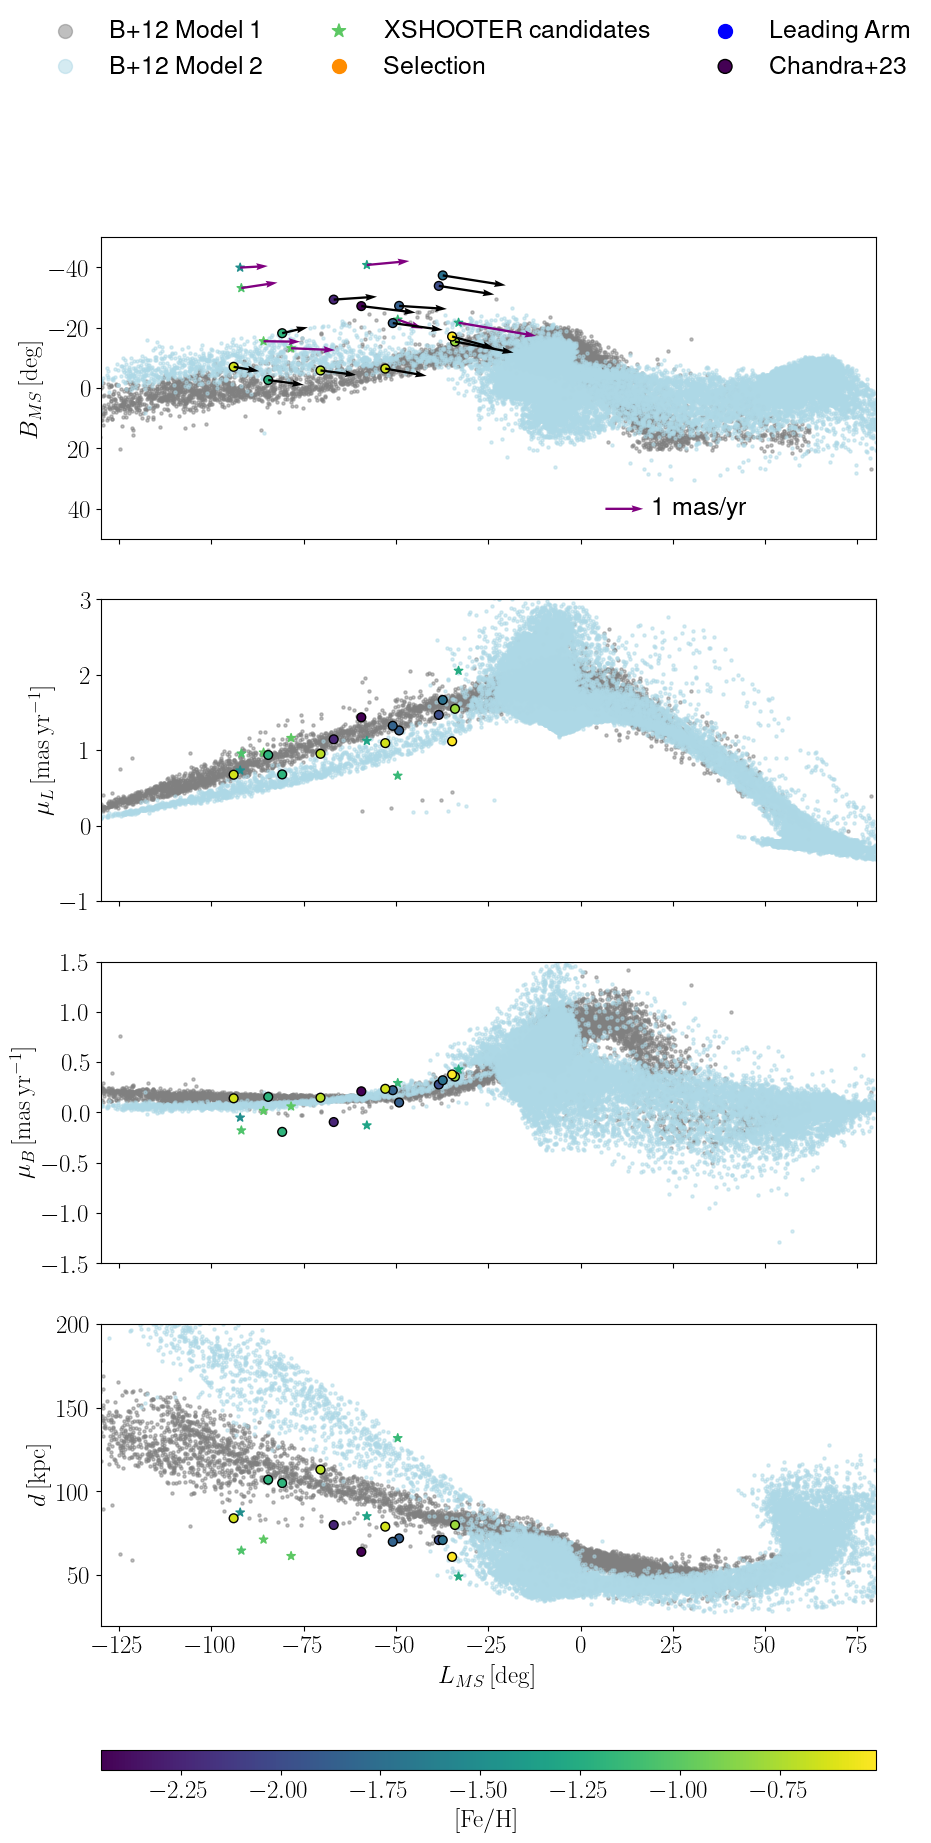

In [272]:
import matplotlib.lines as mlines
import matplotlib as mpl

# --- NEW: choose how "long" 1 mas/yr looks in degrees on the plot
pm_scale_deg = 10.25  # deg per (mas/yr); increase for longer arrows

fig, ax = plt.subplots(4, 1, figsize=(20/2, 40/2), sharex=True)
dot_size = 5
dot_size_sel = 20

color_selection = 'darkorange'
color_all = 'k'
color_leading = 'blue'
color_xshooter = 'purple'

x = np.linspace(-130, 80, 100)

# -----------------------------
# NEW: shared FeH normalization
# -----------------------------
feh_all = np.concatenate([
    np.asarray(xshooter_candidates['feh']),
    np.asarray(chandra['feh'])
])
feh_all = feh_all[np.isfinite(feh_all)]
norm_feh = mpl.colors.Normalize(vmin=feh_all.min(), vmax=feh_all.max())
cmap_feh = mpl.cm.viridis  # change if you want

# Panel 0: (L,B) with proper-motion vectors
ax[0].scatter(smc1_sim['L_stream'], smc1_sim['B_stream'], s=dot_size, color='gray', label='B+12 Model 1', alpha=0.5)
ax[0].scatter(smc2_sim['L_stream'], smc2_sim['B_stream'], s=dot_size, color='lightblue', label='B+12 Model 2', alpha=0.5)

# xshooter coloured by feh
sc_x0 = ax[0].scatter(
    xshooter_candidates['L_stream'], xshooter_candidates['B_stream'],
    s=dot_size_sel*2, c=xshooter_candidates['feh'], cmap=cmap_feh, norm=norm_feh,
    label='XSHOOTER candidates', marker='*'
)

# quiver for xshooter observed stars (keep a single color for arrows)
q_xshooter = ax[0].quiver(
    xshooter_candidates['L_stream'], xshooter_candidates['B_stream'],
    pm_scale_deg*xshooter_candidates['pm_l'], pm_scale_deg*xshooter_candidates['pm_b'],
    angles='xy', scale_units='xy', scale=1, width=0.003, color=color_xshooter
)

ax[0].scatter([], [], c=color_selection, label='Selection')
ax[0].scatter([], [], c=color_leading, s=dot_size_sel*2, label='Leading Arm')

ax[0].set_xlim(-130, 80)
ax[0].set_ylim(-50, 50)
ax[0].set_ylabel(r'$B_{MS} \,[\mathrm{deg}]$')

ax[0].quiverkey(q_xshooter, 0.7, 0.10, pm_scale_deg*1.0, r'1 mas/yr', labelpos='E', coordinates='axes')

# chandra coloured by feh
sc_c0 = ax[0].scatter(
    chandra['L_stream'], chandra['B_stream'],
    s=dot_size_sel*2, c=chandra['feh'], cmap=cmap_feh, norm=norm_feh,
    label='Chandra+23', edgecolors='k'
)
q_chandra = ax[0].quiver(
    chandra['L_stream'], chandra['B_stream'],
    pm_scale_deg*chandra['pm_l'], pm_scale_deg*chandra['pm_b'],
    angles='xy', scale_units='xy', scale=1, width=0.003, color='k'
)

ax[0].set_ylim(50, -50)
ax[0].set_xlim(-130, 80)

# --- Create a single legend for the whole figure ---
handles, labels = ax[0].get_legend_handles_labels()
lg = fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1),
    ncol=3,
    frameon=False
)
for handle in lg.legend_handles:
    try:
        handle.set_sizes([100])
    except AttributeError:
        pass

# Panel 1: μ_L vs L
ax[1].scatter(smc1_sim['L_stream'], smc1_sim['pm_l'], s=dot_size, color='gray', label='B+12 Model 1', alpha=0.5)
ax[1].scatter(smc2_sim['L_stream'], smc2_sim['pm_l'], s=dot_size, color='lightblue', label='B+12 Model 2', alpha=0.5)

ax[1].scatter(
    xshooter_candidates['L_stream'], xshooter_candidates['pm_l'],
    s=dot_size_sel*2, c=xshooter_candidates['feh'], cmap=cmap_feh, norm=norm_feh,
    label='Observed with XSHOOTER', marker='*'
)
ax[1].scatter(
    chandra['L_stream'], chandra['pm_l'],
    s=dot_size_sel*2, c=chandra['feh'], cmap=cmap_feh, norm=norm_feh,
    label='Chandra+23', edgecolors='k'
)
ax[1].set_ylabel(r'$\mu_{L} \,[\mathrm{mas\,yr^{-1}}]$')
ax[1].set_ylim(-1, 3)

# Panel 2: μ_B vs L
ax[2].scatter(smc1_sim['L_stream'], smc1_sim['pm_b'], s=dot_size, color='gray', label='B+12 Model 1', alpha=0.5)
ax[2].scatter(smc2_sim['L_stream'], smc2_sim['pm_b'], s=dot_size, color='lightblue', label='B+12 Model 2', alpha=0.5)

ax[2].scatter(
    xshooter_candidates['L_stream'], xshooter_candidates['pm_b'],
    s=dot_size_sel*2, c=xshooter_candidates['feh'], cmap=cmap_feh, norm=norm_feh,
    label='Observed with XSHOOTER', marker='*'
)
ax[2].scatter(
    chandra['L_stream'], chandra['pm_b'],
    s=dot_size_sel*2, c=chandra['feh'], cmap=cmap_feh, norm=norm_feh,
    label='Chandra+23', edgecolors='k'
)
ax[2].set_ylabel(r'$\mu_{B} \,[\mathrm{mas\,yr^{-1}}]$')
ax[2].set_ylim(-1.5, 1.5)

# Panel 3: distance vs L
ax[3].scatter(smc1_sim['L_stream'], smc1_sim['distance'], s=dot_size, color='gray', label='B+12 Model 1', alpha=0.5)
ax[3].scatter(smc2_sim['L_stream'], smc2_sim['distance'], s=dot_size, color='lightblue', label='B+12 Model 2', alpha=0.5)

ax[3].scatter(
    xshooter_candidates['L_stream'], xshooter_candidates['dist_pc_p50']/1000,
    s=dot_size_sel*2, c=xshooter_candidates['feh'], cmap=cmap_feh, norm=norm_feh,
    label='Observed with XSHOOTER', marker='*'
)
ax[3].scatter(
    chandra['L_stream'], chandra['distance'],
    s=dot_size_sel*2, c=chandra['feh'], cmap=cmap_feh, norm=norm_feh,
    label='Chandra+23', edgecolors='k'
)
ax[3].set_ylim(20, 200)
ax[3].set_ylabel(r'$d \,[\mathrm{kpc}]$')
ax[3].set_xlabel(r'$L_{MS} \,[\mathrm{deg}]$')

# -----------------------------
# NEW: one shared horizontal cbar
# -----------------------------
sm = mpl.cm.ScalarMappable(norm=norm_feh, cmap=cmap_feh)
sm.set_array([])  # needed for older mpl

# leave space at bottom for the bar
fig.subplots_adjust(bottom=0.10)

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.08, aspect=40)
cbar.set_label(r'$\mathrm{[Fe/H]}$')

plt.savefig(os.path.join(plots_dir, 'xshooter_proper_motions_feh.png'), dpi=900, bbox_inches='tight')
plt.show()